In [1]:
from pathlib import Path
from track_cells import run_tracker
from analysis_functions import *
from plotting_functions import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:


experiment_folder = '/fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/'

paths = []
paths.append(Path(experiment_folder + '20241114-MCF10A')) # 
paths.append(Path(experiment_folder + '20241118-MCF10A')) # 
paths.append(Path(experiment_folder + '20241121-MCF10A')) # 

# Run tracker for every tif
for path in paths:
    for filename in sorted(path.glob("*.tif")):
        sub_path = Path(filename.parent, filename.stem)
        run_tracker(
            nuc_label_path  = Path(sub_path, "all_nuc_masks.tif"),
            cell_label_path = Path(sub_path, "all_cyto_masks.tif"),
            stem            = filename.stem,
            sub_path        = sub_path,
        )

# Then as before
analysis = ImageProcessor(paths, mode="trackmate")
analysis.process_images()
analysis.normalize_variables(avg_over_n=5)





[tracker] Loading nuclear labels  : /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/20241114-MCF10A/18_235D_EGF_3/all_nuc_masks.tif
[tracker] Loading cell-body labels: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/20241114-MCF10A/18_235D_EGF_3/all_cyto_masks.tif
[tracker] Stack shape: T=193, H=973, W=973
[tracker] Computing per-frame nucleus ↔ cell associations …
[tracker] Linking detections frame-by-frame …
[tracker] Running gap closing …
[tracker] Gap closing merged 0 track pairs.
[tracker] Length filter (>=40 frames): 1813 → 572 tracks kept
[tracker] Painting output label stack …
[tracker] Building spots CSV …
[tracker] Writing → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/20241114-MCF10A/18_235D_EGF_3/LblImg_18_235D_EGF_3_trackfile.tif
[tracker] Writing → /fml/ag-ramm/projects/Protease_bios

In [4]:
condition_list = list(analysis.df.index.get_level_values(0).unique())
condition_list

['235D_EGF']

In [158]:
analysis.df.columns.tolist()

['FR_nuc',
 'FR_mem',
 'GFP_nuc',
 'GFP_mem',
 'BFP_nuc',
 'BFP_mem',
 'iRFP_nuc',
 'iRFP_mem',
 'nuc_area',
 'mem_area',
 'cell_area',
 'FR_nuc_conc',
 'FR_mem_conc',
 'GFP_nuc_conc',
 'GFP_mem_conc',
 'BFP_nuc_conc',
 'BFP_mem_conc',
 'iRFP_nuc_conc',
 'iRFP_mem_conc',
 'FR_nuc_mem_ratio',
 'FR_nuc_mem_conc_ratio',
 'GFP_nuc_mem_conc_ratio',
 'BFP_nuc_mem_conc_ratio',
 'iRFP_nuc_mem_conc_ratio',
 'GFP_iRFP_mem_ratio',
 'FR_BFP_nuc_ratio',
 'FR_iRFP_mem_ratio',
 'GFP_FR_mem_ratio',
 'FR_GFP_mem_ratio',
 'iRFP_cr',
 'BFP_cr',
 'FR_cr',
 'cr_area',
 'iRFP_cr_conc',
 'iRFP_cr_nuc_ratio',
 'iRFP_cr_nuc_conc_ratio',
 'BFP_cr_conc',
 'BFP_cr_nuc_ratio',
 'BFP_cr_nuc_conc_ratio',
 'FR_cr_conc',
 'FR_cr_nuc_ratio',
 'FR_cr_nuc_conc_ratio']

In [6]:

palette2 = {
         "FR_nuc_mem_conc_ratio":  "#aa3377",
        "iRFP_cr_nuc_conc_ratio": "#292562",
        "BFP_nuc_mem_conc_ratio": "#BBBBBB", #darker gray
        "BFP_cr_nuc_conc_ratio":  "#DDDDDD",  #lighter gray
         "FR_nuc_conc":  "#aa3377",
        "iRFP_nuc_conc": "#292562",
        "BFP_nuc_conc": "#BBBBBB",

    }



In [7]:
plotter = PlotHelper(analysis, 
                     palette=palette2, 
                     save_outputs=True, 
                     out_dir=experiment_folder + "plot_exports",
                     
                    )
plotter.set_time_axis(dt=5, unit="mins", t_zero=-25)  
# 5 frames then addition of EGF, mineral oil, 5 min interval

[filter] After exclude_nuc_zero: 117 cells
[filter] After exclude_short_tracks (min_track_length=100): 117 cells
[filter] Final valid cells: 117
Selected cell — condition: '235D_EGF', folder: 2, repeat_id: 17, object_id: 139


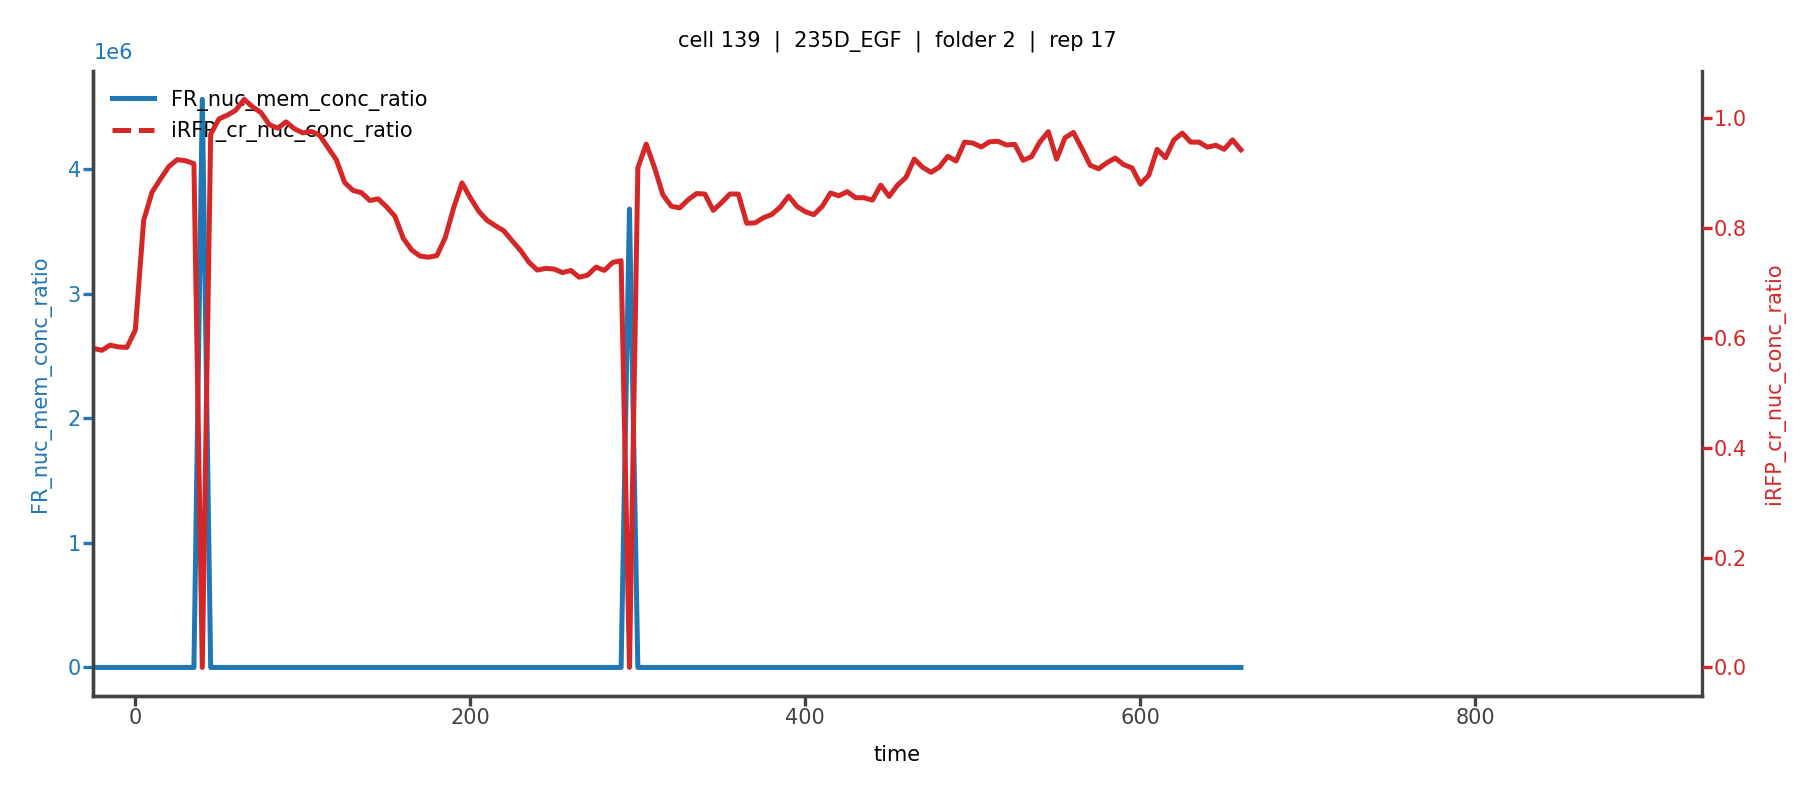

In [8]:
conditions = ['235D_EGF']
variables = ['FR_nuc_mem_conc_ratio']

ret_data = plotter.plot_single_cell_dual('FR_nuc_mem_conc_ratio', 
                              'iRFP_cr_nuc_conc_ratio',
        conditions=conditions, detrend=False, smooth_sigma=2.5,
        exclude_dividing=False,
        exclude_late_start=False,
        min_track_start=0,
        exclude_nuc_zero=True,
        exclude_short_tracks=True,
        min_track_length=100,
                             )

In [253]:
vars = ["FR_nuc_mem_conc_ratio", 
        "iRFP_cr_nuc_conc_ratio",
        "BFP_nuc_mem_conc_ratio", 
        "BFP_cr_nuc_conc_ratio"]
# vars = ["FR_nuc_conc", 
#          "iRFP_nuc_conc",
#          "BFP_nuc_conc"]
invert_vars = None 
# invert_vars = ['iRFP_nuc_conc']

outlier_clip=5 # 5for ratios #None for conc

In [254]:
# Step 1 — build and inspect the signal dataframe:

var_params={
        "iRFP_cr_nuc_conc_ratio": {
            "detrend": True,      # no detrending for iRFP
            "detrend_mode": "percentile",   
            "poly_degree": 2,               # only used if mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False,
            "baseline_window": 41, #41 
            "baseline_pct": 50,#50
            "smooth_sigma": 2.0, #2.0
        },
        "BFP_cr_nuc_conc_ratio": {
            "detrend": True,      # no detrending for iRFP
            "detrend_mode": "percentile",   
            "poly_degree": 2,               # only used if mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False,
            "baseline_window": 41, #41 
            "baseline_pct": 50,#50
            "smooth_sigma": 2.0, #2.0
        },
        "FR_nuc_mem_conc_ratio": {
            "detrend": True,
            "detrend_mode": "percentile",  
            "poly_degree": 2,              # only used if mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False,
            "baseline_window": 41, #41 
            "baseline_pct": 50,#50
            "smooth_sigma": 2.0, #2.0
        },
        "BFP_nuc_mem_conc_ratio": {
            "detrend": True, #True
            "detrend_mode": "percentile",   
            "poly_degree": 2,               # only used if mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False, #False
            "baseline_window": 41, #41 
            "baseline_pct": 50,#50
            "smooth_sigma": 2.0, #2.0
        },
}

df_indexed = plotter.build_signal_df(
    vars=vars,
    var_params=var_params,
    invert_vars=invert_vars,
    conditions=["235D_EGF"],
    exclude_dividing=True, #includes dividing and non-dividing cells
    frame_range=[0,130],
    min_track_start=5,
    min_coverage=0.9,
    outlier_clip=outlier_clip,
    interpolate_gaps=True,
)

# raw one for the representative trace plot
df_indexed_raw = plotter.build_signal_df(
    vars=vars,
    invert_vars=invert_vars,
    conditions=["235D_EGF"],
    exclude_dividing=True, #includes all
    frame_range=[0,130],#before 130 only
    min_track_start=5, 
    detrend=False,
    min_coverage=0.9,
    outlier_clip=outlier_clip,
    interpolate_gaps=False, # to have the gaps that are acutaly NaN otherwise set to true
)

# Inspect — should be 0-2 range, no crazy outliers
df_indexed.describe()

[build_signal_df] FR_nuc_mem_conc_ratio: 763/4312 cells pass coverage>=0.9
[build_signal_df] iRFP_cr_nuc_conc_ratio: 763/4312 cells pass coverage>=0.9
[build_signal_df] BFP_nuc_mem_conc_ratio: 763/4312 cells pass coverage>=0.9
[build_signal_df] BFP_cr_nuc_conc_ratio: 763/4312 cells pass coverage>=0.9
[build_signal_df] shape=(96568, 4)
       FR_nuc_mem_conc_ratio  iRFP_cr_nuc_conc_ratio  BFP_nuc_mem_conc_ratio  \
count             95896.0000              95894.0000              95896.0000   
mean                  0.0076                 -0.0021                 -0.0036   
std                   0.1061                  0.1030                  0.0568   
min                  -0.4849                 -0.6313                 -0.4364   
25%                  -0.0462                 -0.0416                 -0.0226   
50%                  -0.0001                  0.0002                 -0.0004   
75%                   0.0505                  0.0400                  0.0200   
max                   2

,FR_nuc_mem_conc_ratio,iRFP_cr_nuc_conc_ratio,BFP_nuc_mem_conc_ratio,BFP_cr_nuc_conc_ratio
count,95896.000000,95894.000000,95896.000000,95894.000000
mean,0.007561,-0.002082,-0.003603,0.008138
std,0.106102,0.102967,0.056823,0.054985
min,-0.484895,-0.631345,-0.436376,-0.363707
25%,-0.046173,-0.041606,-0.022598,-0.013618
50%,-0.000114,0.000187,-0.000393,0.000901
75%,0.050524,0.039951,0.020037,0.018257
max,2.893025,0.997465,0.737562,0.840314


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/1_FR_NM_ratio_FRorder_first.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/1_FR_NM_ratio_FRorder_first_points.csv


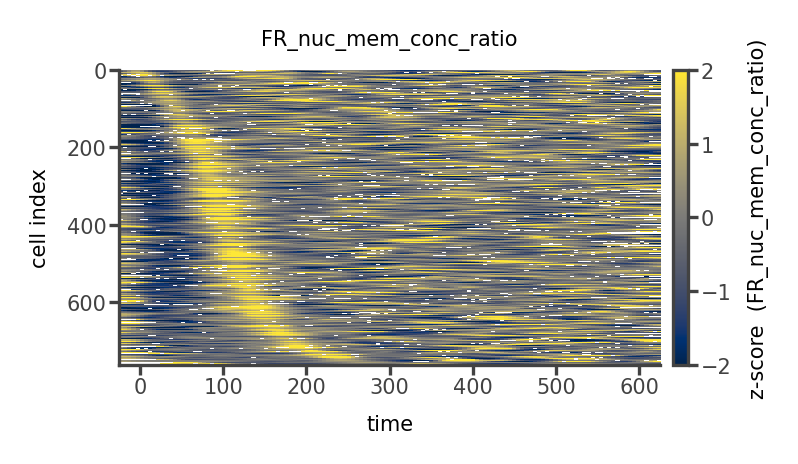

In [255]:
result = plotter.plot_heatmap(
    var       = "FR_nuc_mem_conc_ratio",
    df_indexed = df_indexed,             # from build_signal_df
    figsize   = (2.7, 1.5),
    file_stem = "1_FR_NM_ratio_FRorder_first",
)

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/2_iRFP_CN_ratio_FRorder_first.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/2_iRFP_CN_ratio_FRorder_first_points.csv


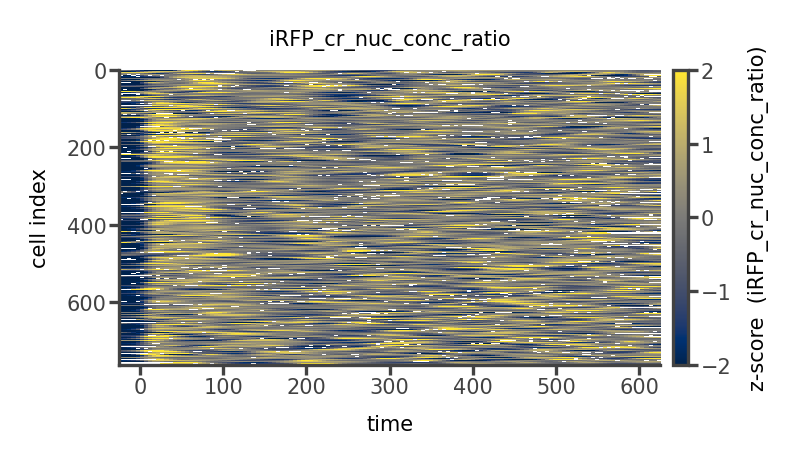

In [256]:
plotter.plot_heatmap(
    cell_order=result["cell_order"],
    var       = "iRFP_cr_nuc_conc_ratio",
    df_indexed = df_indexed,             # from build_signal_df
    figsize   = (2.7, 1.5),
    file_stem = "2_iRFP_CN_ratio_FRorder_first",
);


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/3_BFP_CN_ratio_FRorder_first.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/3_BFP_CN_ratio_FRorder_first_points.csv


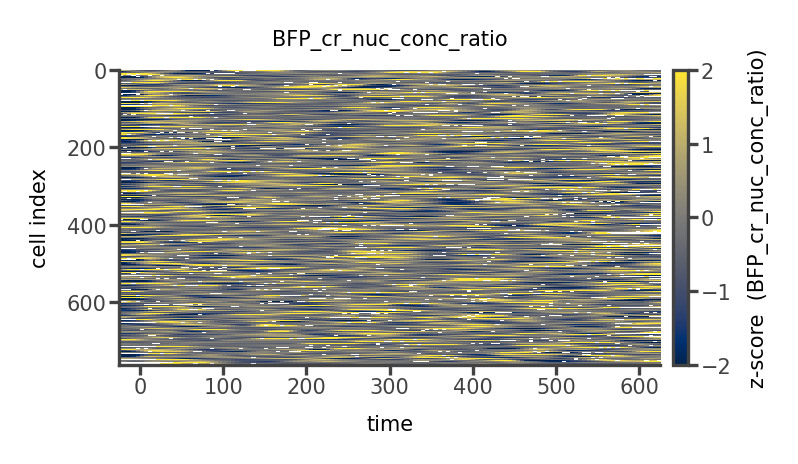

In [257]:
plotter.plot_heatmap(
    cell_order=result["cell_order"],
    var       = "BFP_cr_nuc_conc_ratio",
    df_indexed = df_indexed,             # from build_signal_df
    figsize   = (2.7, 1.5),
    file_stem = "3_BFP_CN_ratio_FRorder_first",
);


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/4_iRFP_CN_ratio_iRFPorder_first.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/4_iRFP_CN_ratio_iRFPorder_first_points.csv


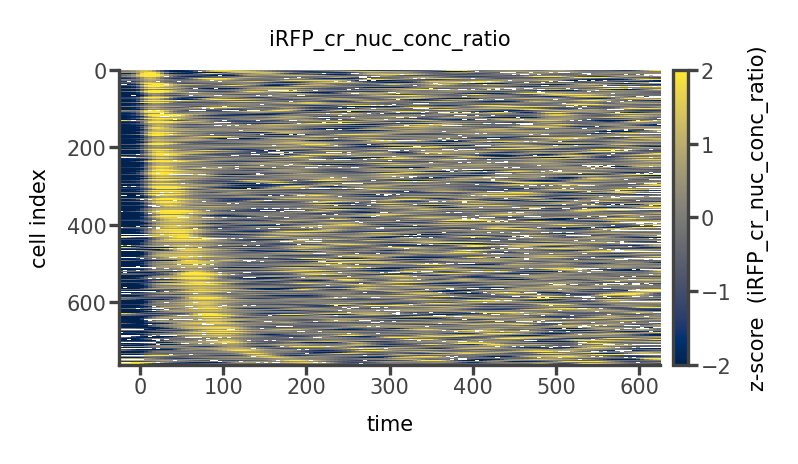

In [258]:
result = plotter.plot_heatmap(
    var       = "iRFP_cr_nuc_conc_ratio",
    df_indexed = df_indexed,             # from build_signal_df
    figsize   = (2.7, 1.5),
    file_stem = "4_iRFP_CN_ratio_iRFPorder_first",
)

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/5_FR_NM_ratio_iRFPorder_first.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/5_FR_NM_ratio_iRFPorder_first_points.csv


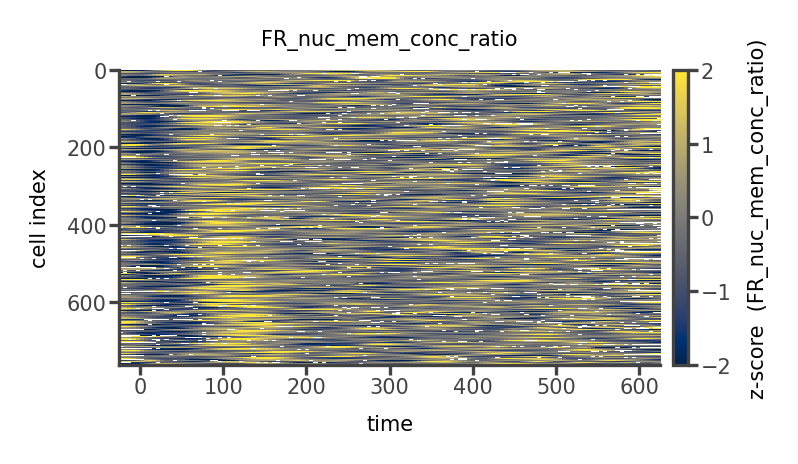

In [259]:
plotter.plot_heatmap(
    cell_order=result["cell_order"],
    var       = "FR_nuc_mem_conc_ratio",
    df_indexed = df_indexed,             # from build_signal_df
    figsize   = (2.7, 1.5),
    file_stem = "5_FR_NM_ratio_iRFPorder_first",
);


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/6_BFP_NM_ratio_iRFPorder_first.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/6_BFP_NM_ratio_iRFPorder_first_points.csv


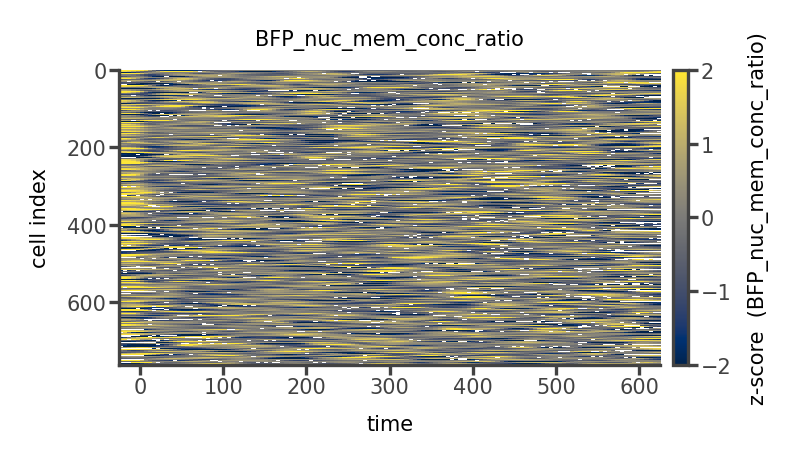

In [260]:
plotter.plot_heatmap(
    cell_order=result["cell_order"],
    var       = "BFP_nuc_mem_conc_ratio",
    df_indexed = df_indexed,             # from build_signal_df
    figsize   = (2.7, 1.5),
    file_stem = "6_BFP_NM_ratio_iRFPorder_first",
);


[find_peaks_per_cell] 1852 peaks found across 756 cells.
[find_peaks_per_cell] 2494 peaks found across 761 cells.
[find_peaks_per_cell] 1711 peaks found across 714 cells.
[find_peaks_per_cell] 2146 peaks found across 739 cells.
  condition folder repeat_id  object_id  peak_frame  peak_value  prominence  \
0  235D_EGF      1        18          6          41    0.047348    0.089051   
1  235D_EGF      1        18          6          82    0.100412    0.167612   
2  235D_EGF      1        18          6         122    0.082389    0.060329   
3  235D_EGF      1        18          9          25    0.167010    0.267285   
4  235D_EGF      1        18          9          65    0.287988    0.427267   

   pulse_number  
0             1  
1             2  
2             3  
3             1  
4             2  


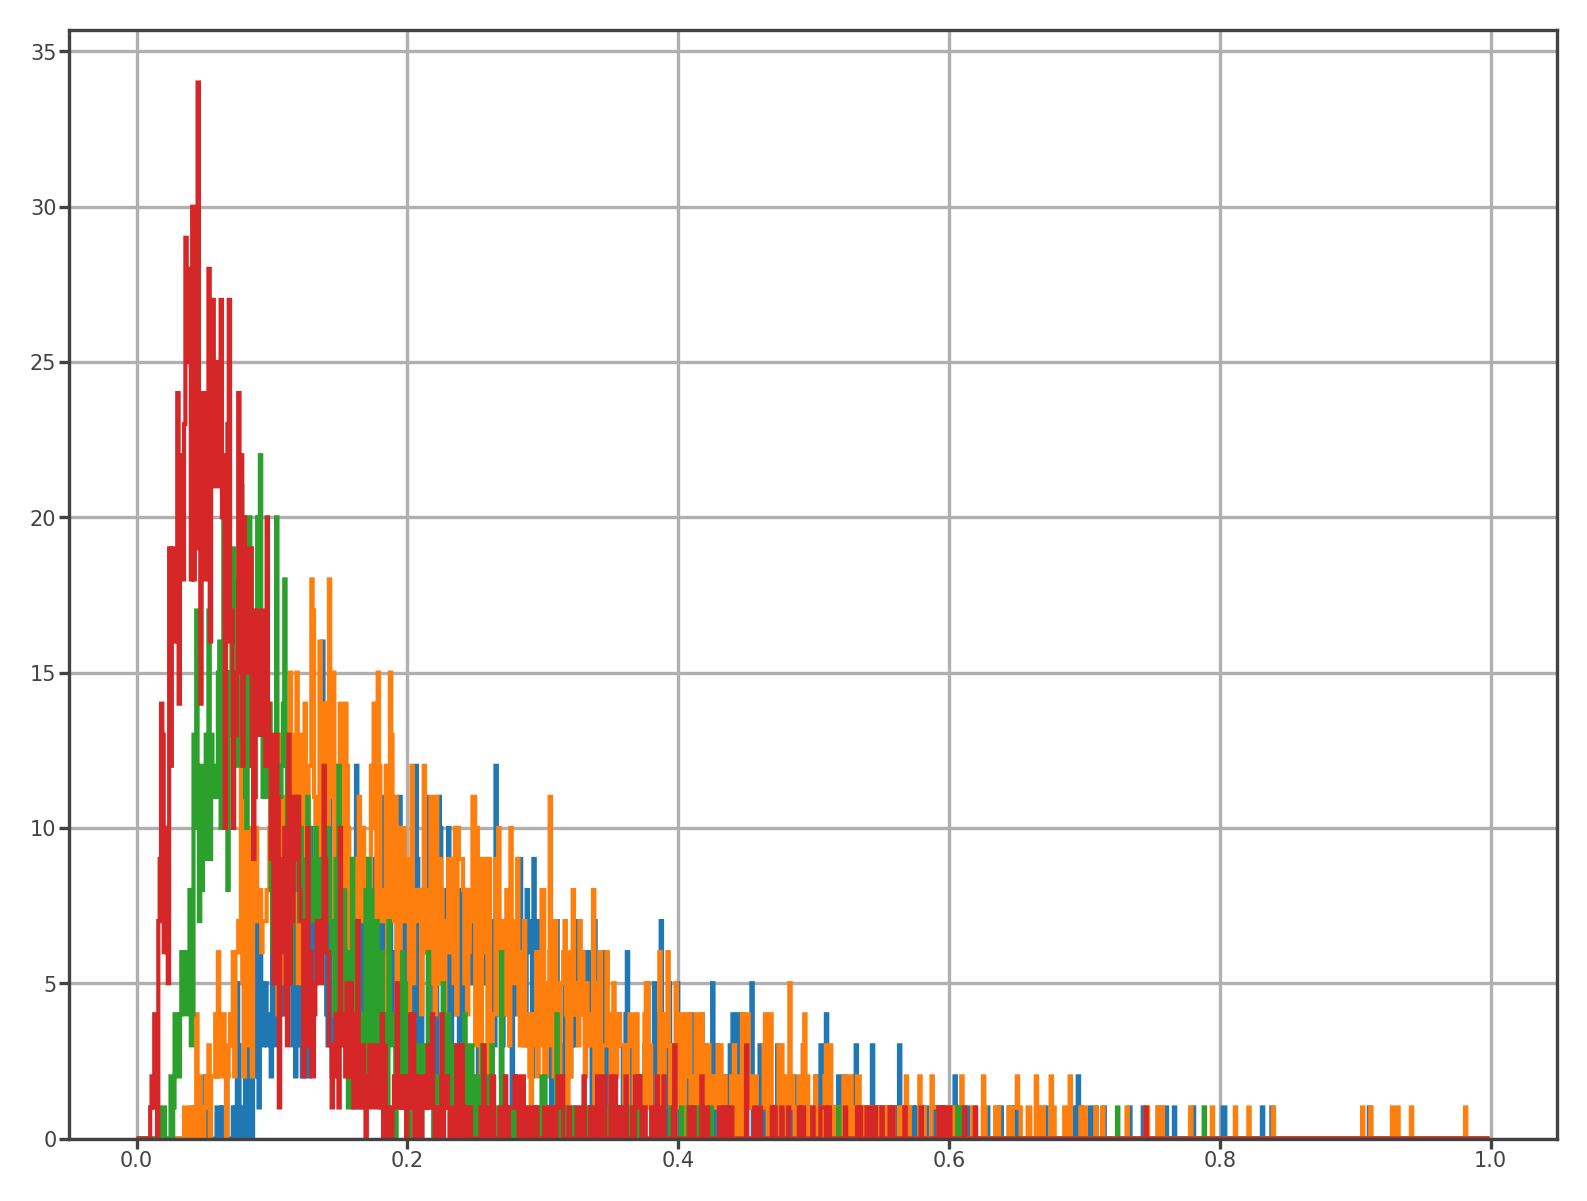

In [261]:
# Step 2 — detect peaks and inspect them:

peak_params={
        "iRFP_cr_nuc_conc_ratio": {
            "prominence": 0.2,# 0.5, 0.3 last
            "relative_prominence": True, #True
            "distance": 5, #5, how close can peaks be together
            "width":3, #suppresses small spikes
            # height=0.06,
        },
        "BFP_cr_nuc_conc_ratio": {
            "prominence": 0.2,# 0.5
            "relative_prominence": True, #True
            "distance": 5, #5, how close can peaks be together
            "width":3, #suppresses small spikes
            # height=0.06,
        },
        "FR_nuc_mem_conc_ratio": {
            "prominence": 0.3,# 0.5
            "relative_prominence": True, #True
            "distance": 5, #5, how close can peaks be together
            "width":3, #suppresses small spikes
            # height=0.06,
        },
        "BFP_nuc_mem_conc_ratio": {
            "prominence": 0.3,# 0.5
            "relative_prominence": True, #True
            "distance": 5, #5, how close can peaks be together
            "width":3, #suppresses small spikes
            # height=0.06,
        },
}

peaks = []
for var in vars:
    new_peak = plotter.find_peaks_per_cell(
        var,
        conditions=["235D_EGF"],
        df_indexed=df_indexed,
        prominence=peak_params[var]['prominence'],
        distance=peak_params[var]['distance'],
        relative_prominence=peak_params[var]['relative_prominence'],
        width=peak_params[var]['width'],
        # height=0.06,
        detrend=False,
    )
    peaks.append(new_peak)

# Inspect — check distribution of peak values and prominences
for peak in peaks:
    peak["prominence"].hist(bins=np.arange(0, 1.0, 0.001), histtype='step')
# peaks[0]["prominence"].hist(bins=30)
print(peaks[0].head())

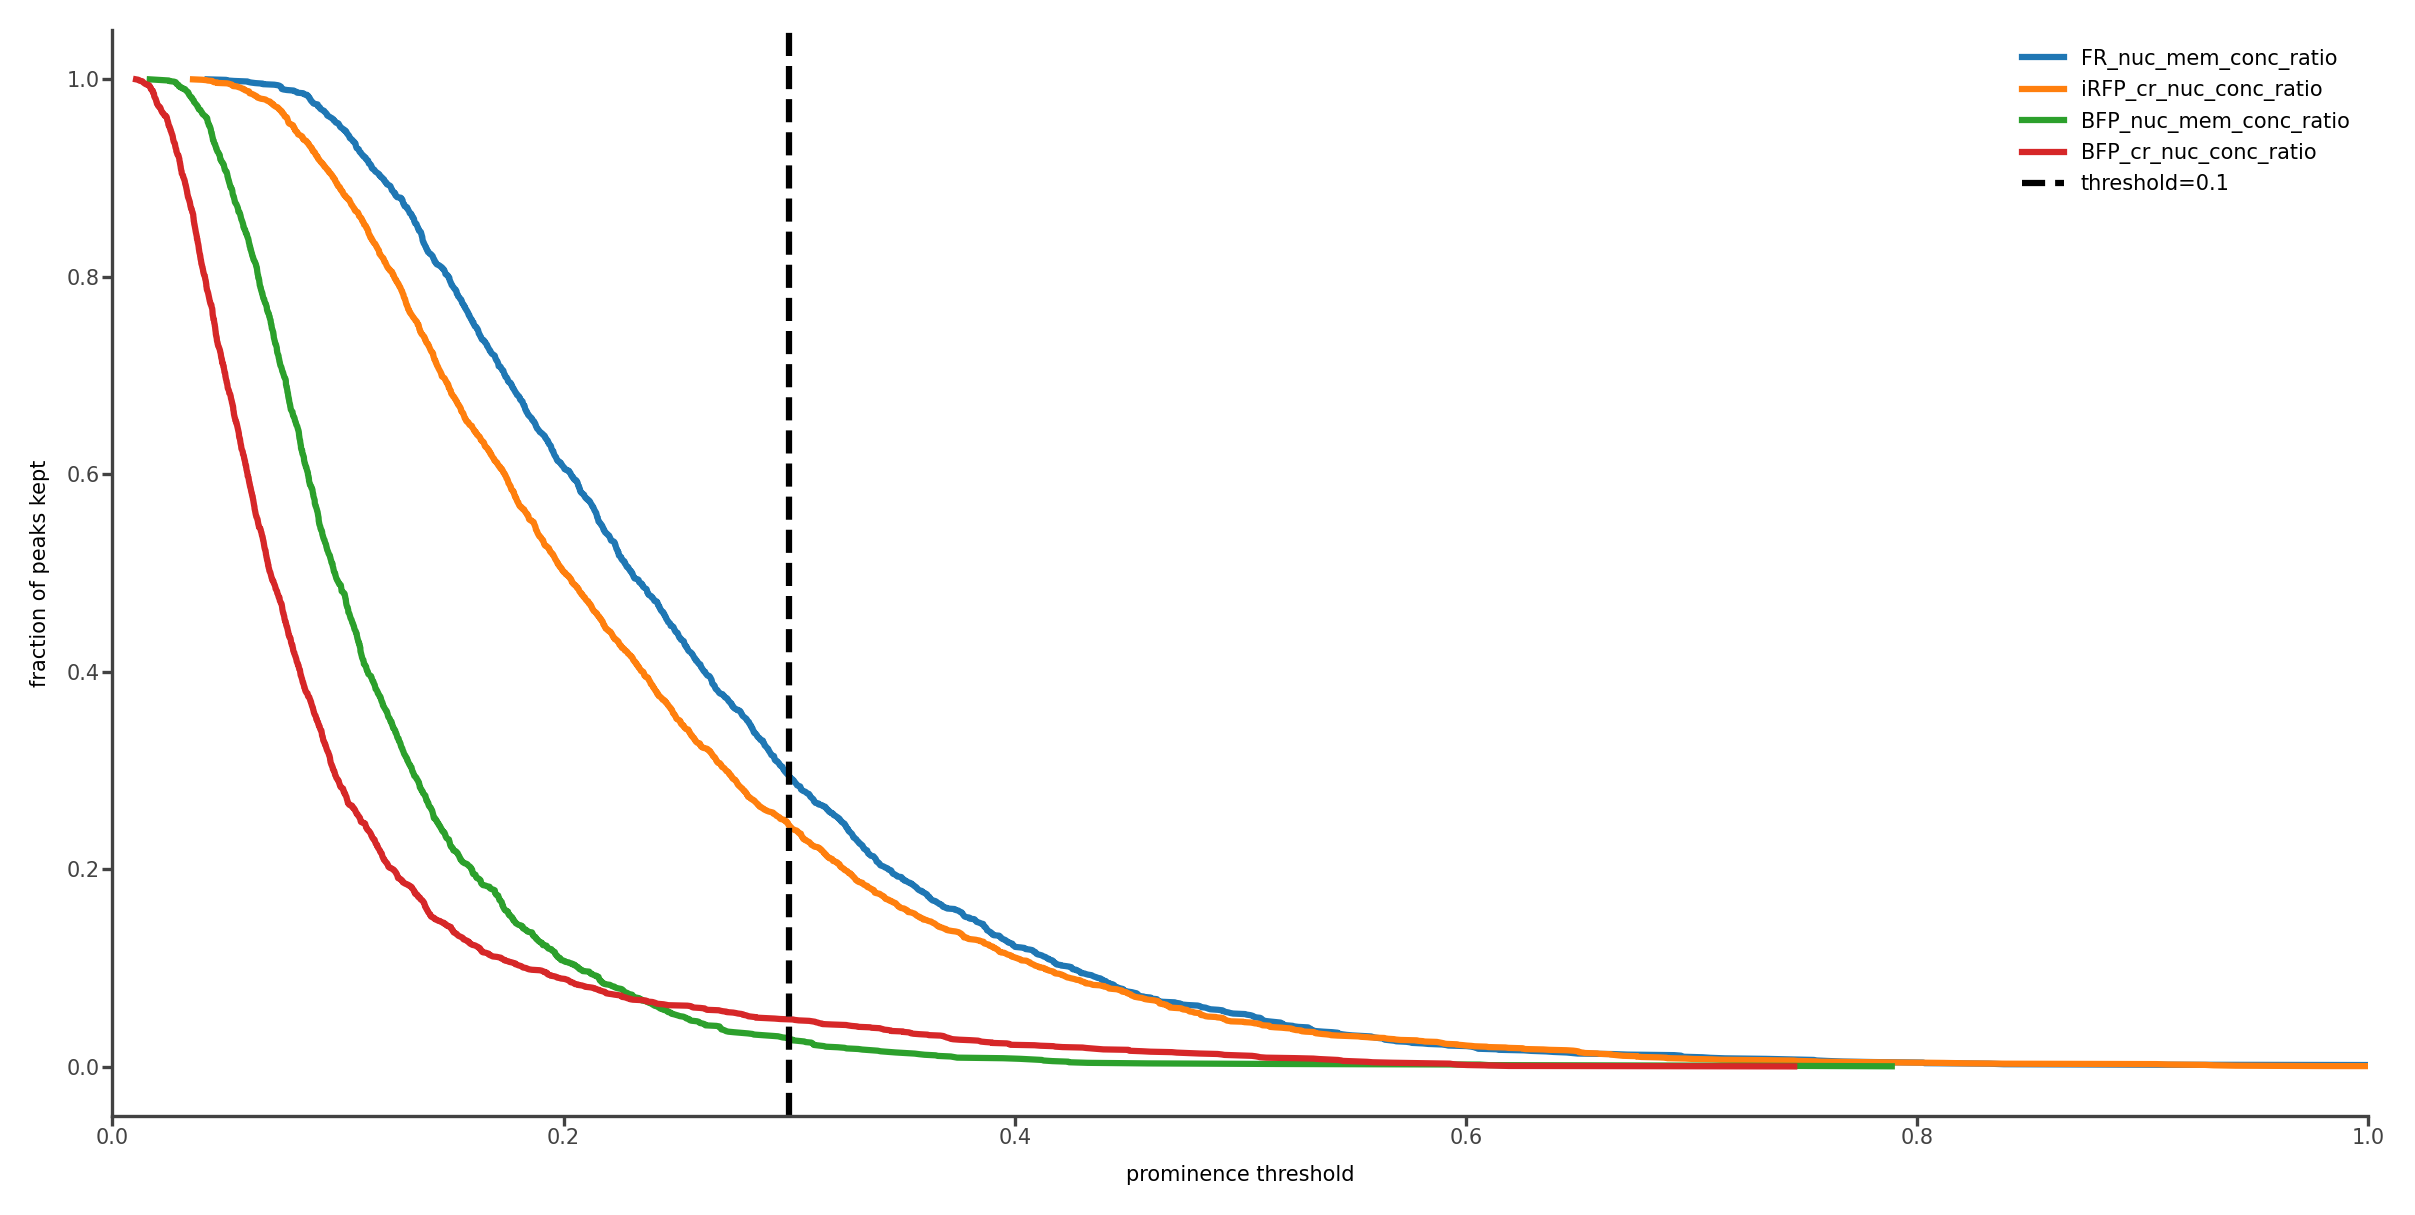

In [262]:
# Plot cumulative fraction to find a threshold that keeps e.g. top 20% of peaks
fig, ax = plt.subplots(figsize=(8, 4))
for peaks_df, var in zip(peaks, vars):
    sorted_prom = np.sort(peaks_df["prominence"].values)
    cdf = np.arange(len(sorted_prom)) / len(sorted_prom)
    ax.plot(sorted_prom, 1 - cdf, label=var)
ax.set_xlabel("prominence threshold")
ax.set_ylabel("fraction of peaks kept")
ax.axvline(0.3, linestyle="--", color="k", label="threshold=0.1")
ax.set_xlim(0, 1.0)    # zoom x axis
# ax.set_ylim(0, 0.5)    # zoom y axis — show only top 50% of peaks
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

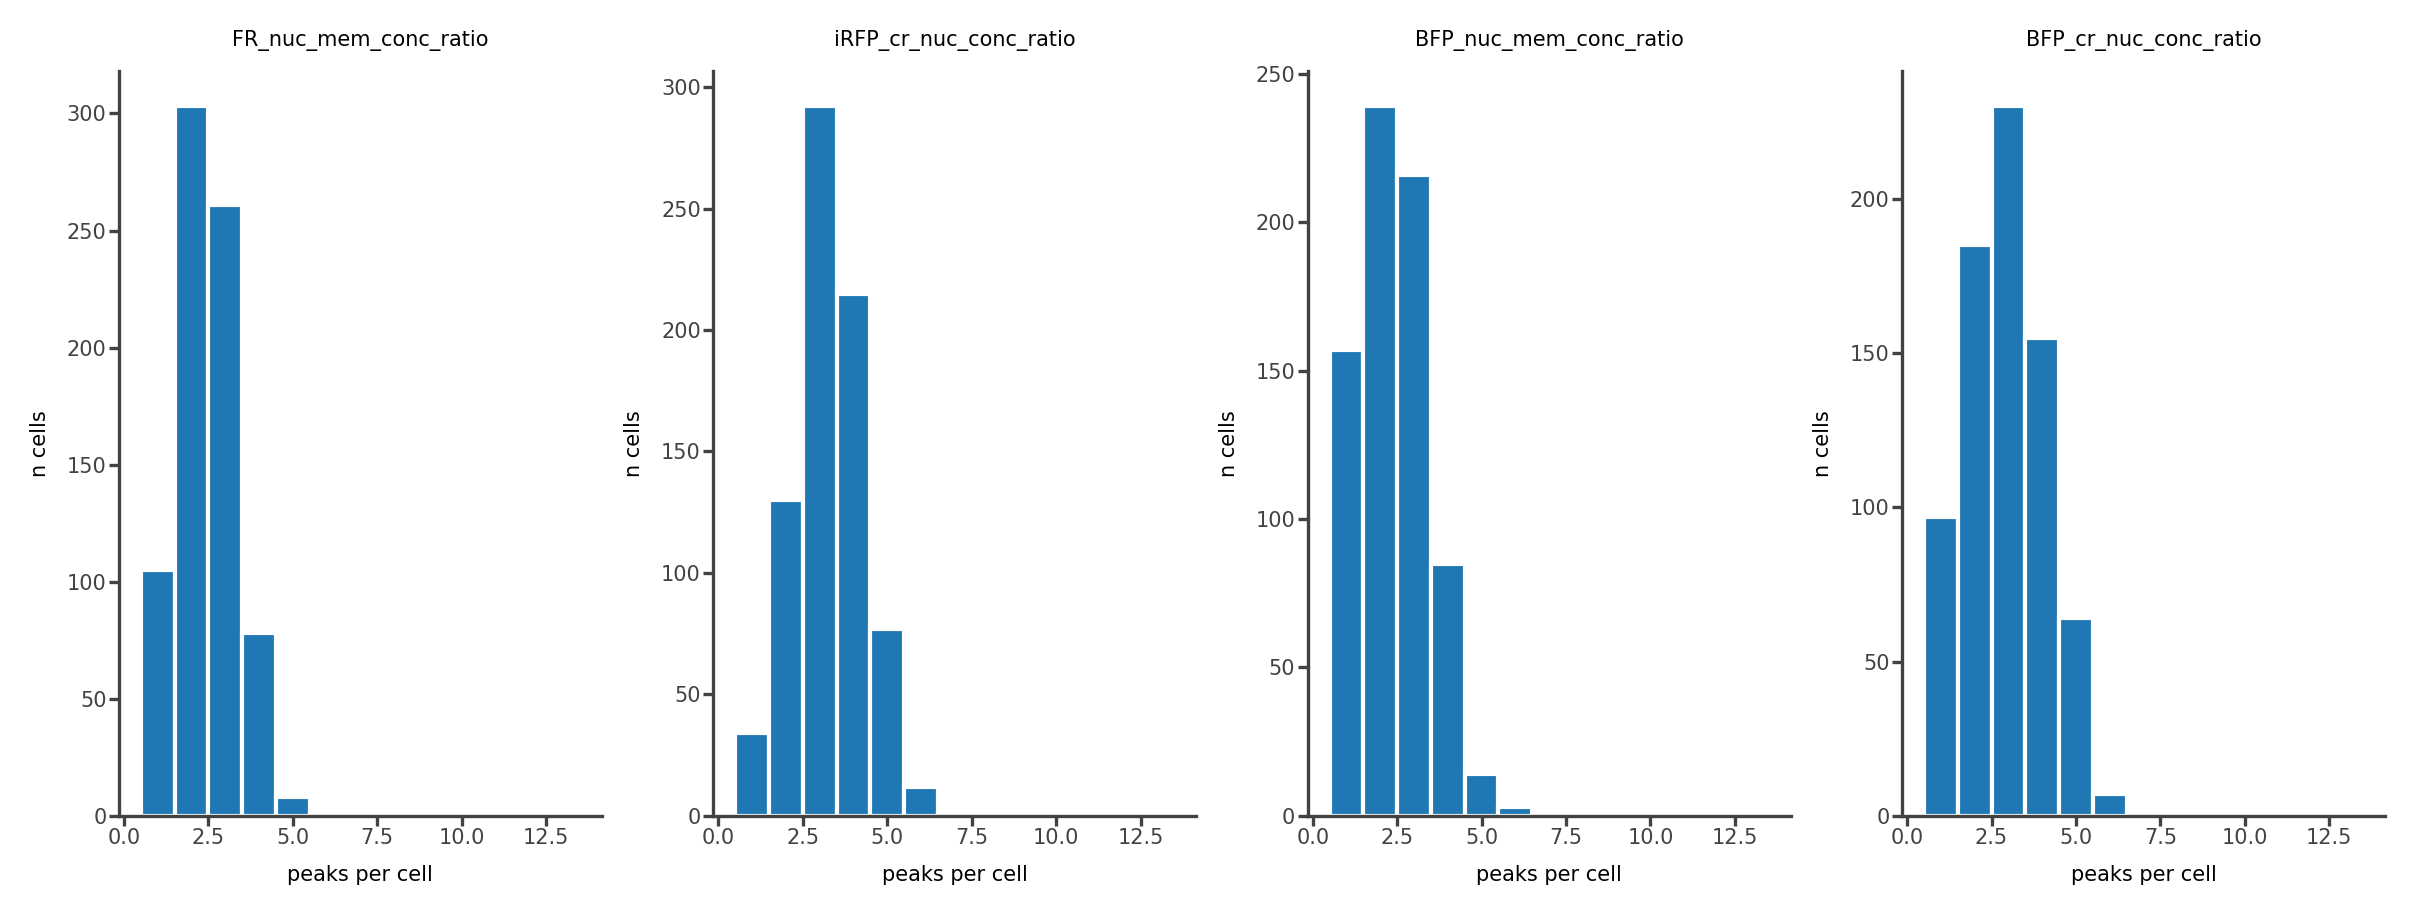

In [263]:
fig, axes = plt.subplots(1, len(peaks), figsize=(8, 3))

for ax, peak, title in zip(
    axes,
    peaks,
    vars
):
    counts = peak.groupby(
        ["condition", "folder", "repeat_id", "object_id"]
    ).size()
    ax.hist(counts.values, bins=range(1, 15), 
            align="left", edgecolor="white")
    ax.set_xlabel("peaks per cell")
    ax.set_ylabel("n cells")
    ax.set_title(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [264]:
for peak, var in zip(peaks, vars):
    counts = peak.groupby(
        ["condition", "folder", "repeat_id", "object_id"]
    ).size()
    print(f"{var}: {counts.mean():.2f} ± {counts.std():.2f} peaks/cell (n={len(counts)})")

FR_nuc_mem_conc_ratio: 2.45 ± 0.90 peaks/cell (n=756)
iRFP_cr_nuc_conc_ratio: 3.28 ± 1.06 peaks/cell (n=761)
BFP_nuc_mem_conc_ratio: 2.40 ± 1.04 peaks/cell (n=714)
BFP_cr_nuc_conc_ratio: 2.90 ± 1.20 peaks/cell (n=739)


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/peak_counts_EGF_ratios.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/peak_counts_EGF_ratios_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/peak_counts_EGF_ratios_summary.csv


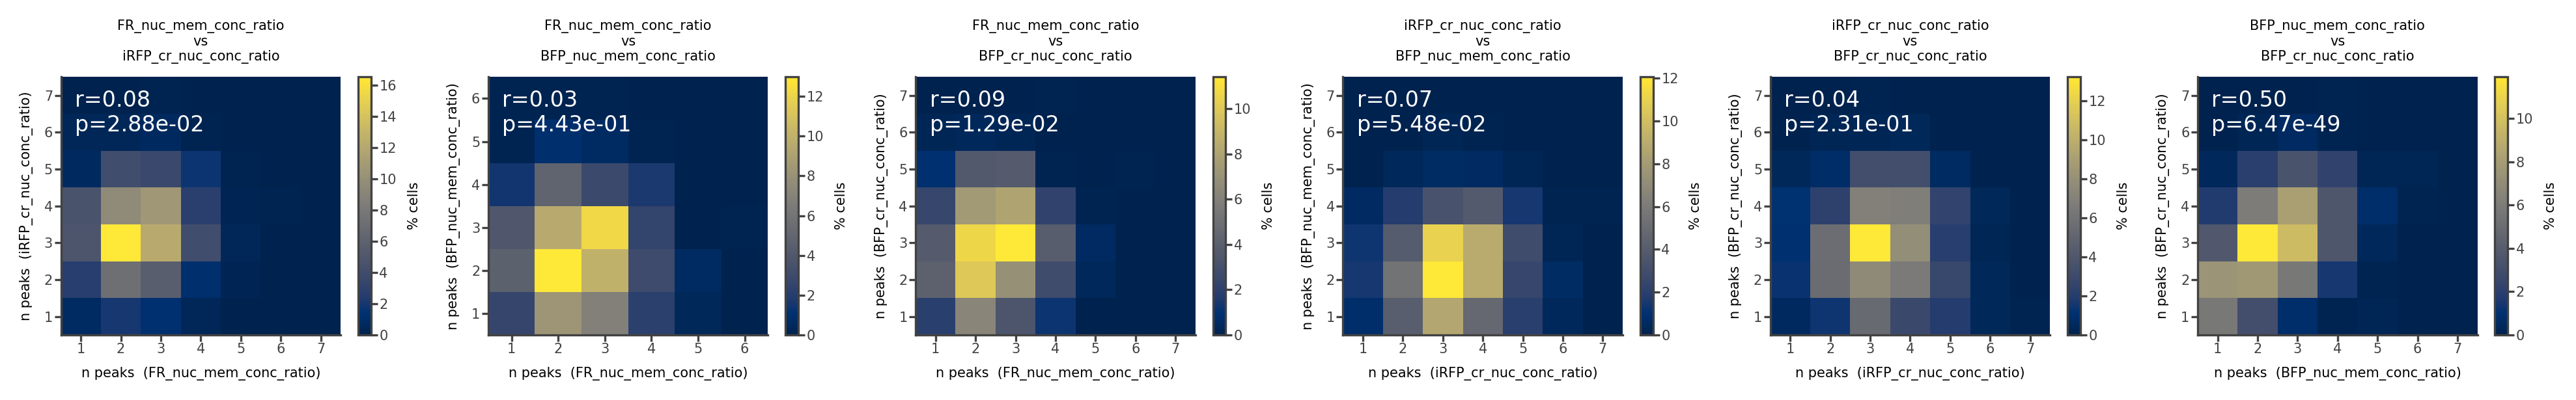

In [193]:
plot_style = {
        'ylim': [0., 0.55],
        'yticks': [0, 0.1,0.2, 0.3, 0.4, 0.5,0.6,0.7],
        'yminorticks': 1,
        'xlim': [-150, 150],
        'xticks': [-200, -100, 0, 100, 200],
        'xminorticks': 2,
}

fig, axes, counts_df = plotter.plot_peak_count_hist2d(
    peaks_list=peaks,
    var_names=[
        "FR_nuc_mem_conc_ratio",
        "iRFP_cr_nuc_conc_ratio",
        "BFP_nuc_mem_conc_ratio",
        "BFP_cr_nuc_conc_ratio",
    ],
    conditions=["235D_EGF"],
    normalize=True,
    file_stem="peak_counts_EGF_ratios",
    figsize=(2.2,2),
)

Plotting cell: {'condition': '235D_EGF', 'folder': '3', 'repeat_id': '19', 'object_id': 199}  (106 candidates)
[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/c235D_EGF-f3-r19-o199_s8_p3.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/c235D_EGF-f3-r19-o199_s8_p3_points.csv


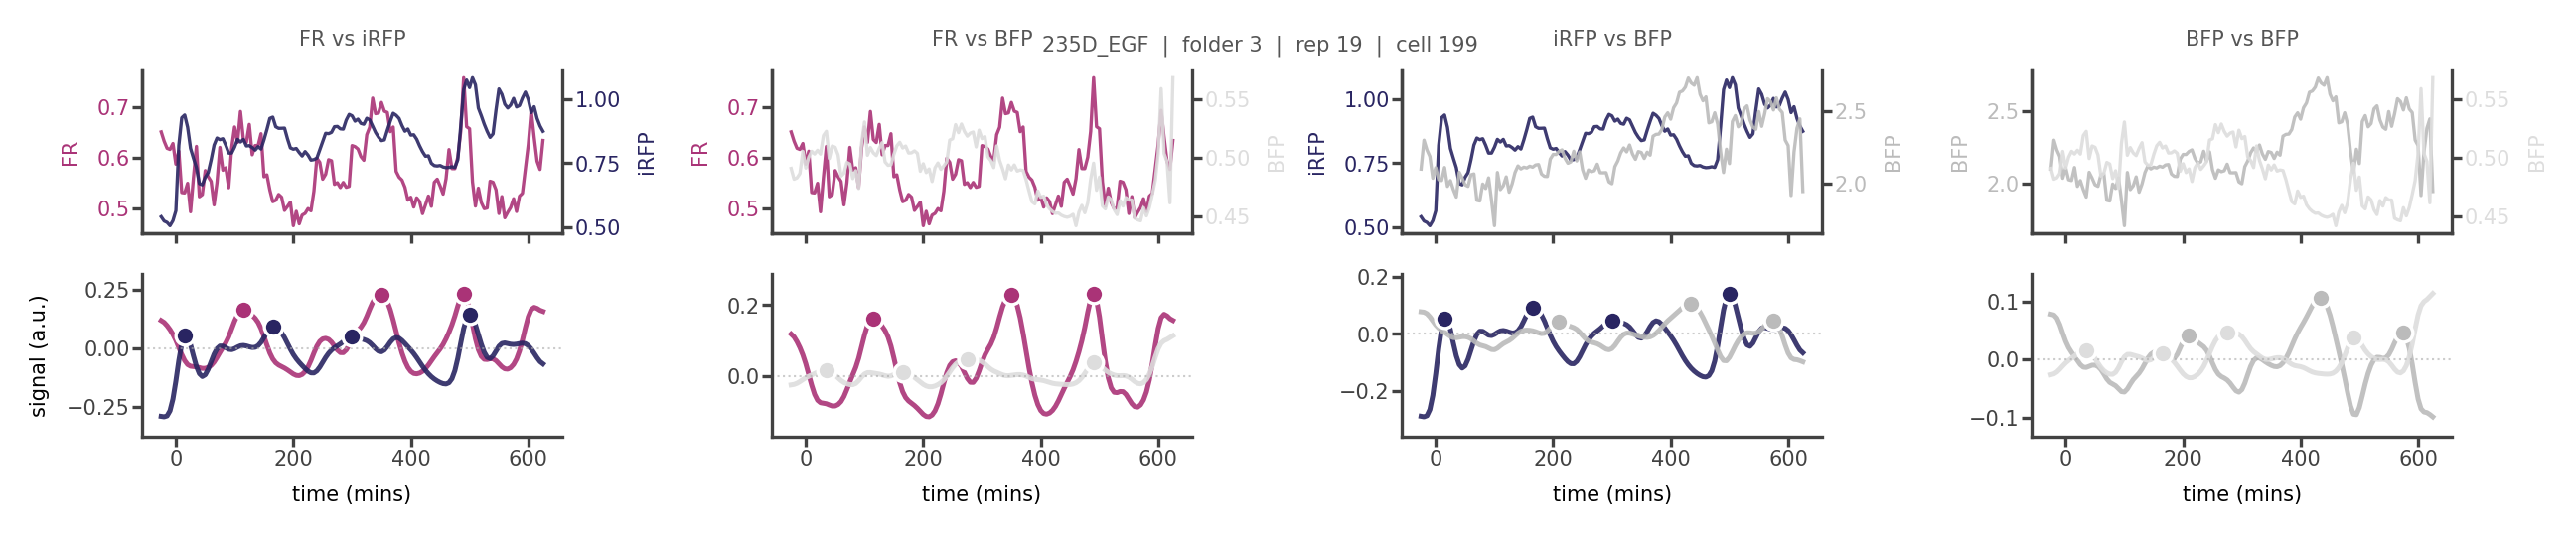

[save_cell_tiffs] Saved crop        → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/celltrack_img_files/c235D_EGF-f3-r19-o199_raw_img.tif
[save_cell_tiffs] Saved outline full → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/celltrack_img_files/c235D_EGF-f3-r19-o199_cell_outline_full.tif
[save_cell_tiffs] Saved outline crop → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/celltrack_img_files/c235D_EGF-f3-r19-o199_cell_outline_crop.tif


PosixPath('/fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/celltrack_img_files')

In [239]:
# Random cell with peaks in all vars
# fig, cell = plot_representative_traces_with_peaks(
#     plotter=plotter,
#     df_raw_indexed=df_indexed_raw,
#     df_proc_indexed=df_indexed,
#     peaks_list=[peaks[0], peaks[1]],
#     vars=[vars[0], vars[1]],
#     colors={
#         vars[0]:  "#aa3377",
#         vars[1]: "#292562",
#     },
#     conditions=["235D_EGF"],
#     seed=42,
#     min_peaks=2,
# )

# Pin to a specific cell found in the hist2d
fig, cell = plotter.plot_representative_traces_with_peaks(
    df_raw_indexed=df_indexed_raw,
    df_proc_indexed=df_indexed,
    peaks_list=[peaks[0], peaks[1],peaks [2], peaks [3]],
    vars=[vars[0],vars[1], vars[2], vars [3]],
    counts_df=counts_df,   # restricts to cells from the hist2d
    conditions=["235D_EGF"],
    pairs=[
        ("FR_nuc_mem_conc_ratio",  "iRFP_cr_nuc_conc_ratio"),
        ("FR_nuc_mem_conc_ratio",  "BFP_cr_nuc_conc_ratio"),
        ("iRFP_cr_nuc_conc_ratio", "BFP_nuc_mem_conc_ratio"),
        ("BFP_nuc_mem_conc_ratio", "BFP_cr_nuc_conc_ratio"),
    ],
    colors={
        vars[0]:  "#aa3377",
        vars[1]: "#292562",
        vars[2]: "#BBBBBB",
        vars[3]: "#DDDDDD",
    },
    
    seed=8,   # for prominence 0.5, seed 5, min_peaks=3 worked well 235D_EGF folder 3 rep 8
    min_peaks=3,
    figsize=(10,1.5),
    #file_stem="test",
 #cell_f3_r8_o203_ratios seed7. minpeak3, cell_f3_r7_o53_s8_p3_ratios, cell_f3_r8_o161_s13_p3_ratios, f3_r8_o197_s15_p3_ratios,cell_f2_r8_o282_s16_p3_ratios, cell_f3_r8_o161_s18_p3_ratios,cell_f3_r19_o83_s19_p3_ratios, cell_f3_r7_o251_s3_p2_ratios,cell_f1_r5_o17_s30_p2_ratios
)


#from plotting_functions import save_cell_tiffs

from plotting_functions import save_cell_tiffs
#save_cell_tiffs(cell, plotter.analysis, plotter, save_crop=False, save_outline=False)
save_cell_tiffs(cell, plotter.analysis, plotter, save_crop=True, save_outline=True)

/fml/ag-ramm/projects/Protease_biosensor/scripts/final_scripts_analysis/plotting_functions.py:5349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _palette = palette or [f"C{i}" for i in range(max_pulses)]
/fml/ag-ramm/projects/Protease_biosensor/scripts/final_scripts_analysis/plotting_functions.py:5349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _palette = palette or [f"C{i}" for i in range(max_pulses)]
/fml/ag-ramm/projects/Protease_biosensor/scripts/final_scripts_analysis/plotting_functions.py:5349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _palette = palette or [f"C{

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/pulse_prominence_EGF_ratios.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/pulse_prominence_EGF_ratios_points.csv


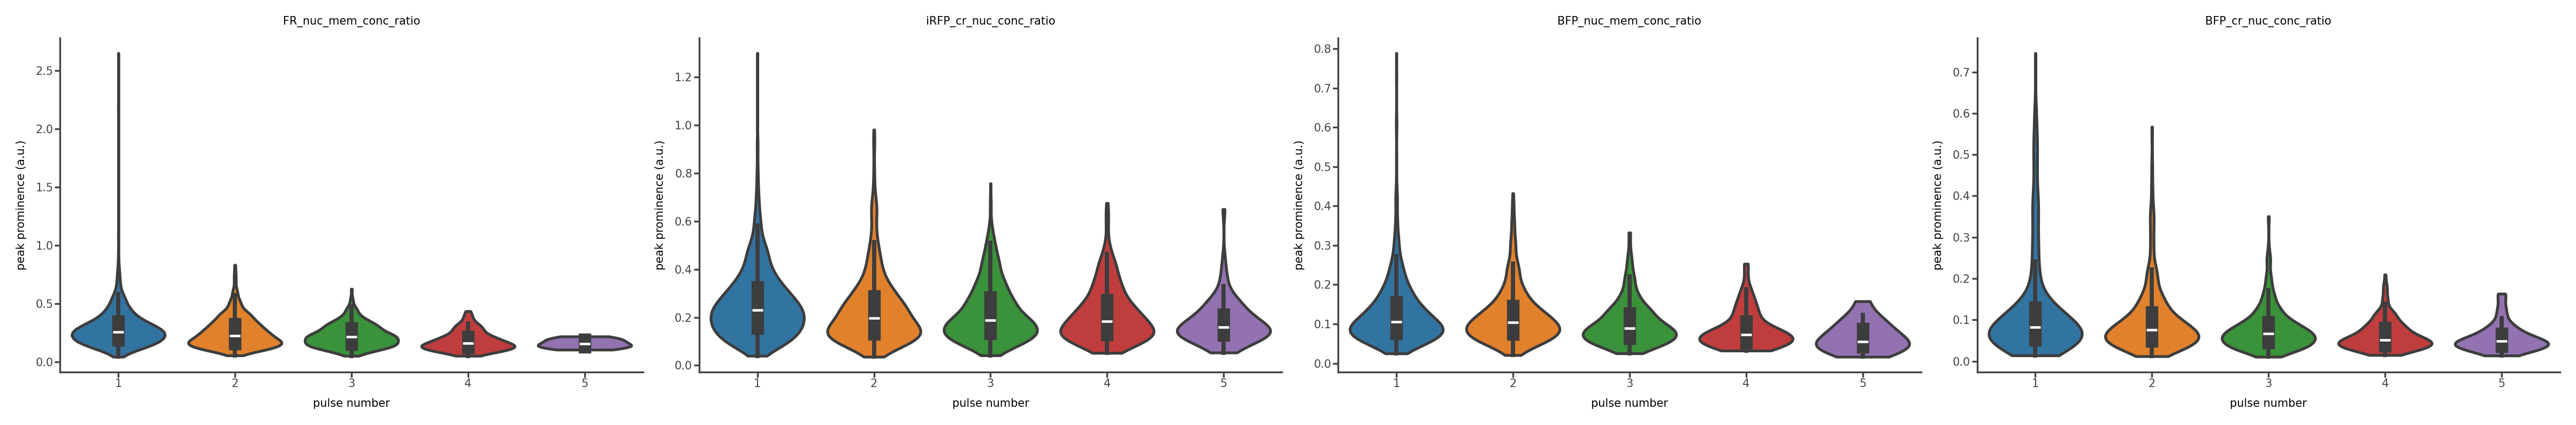

In [195]:
fig, axes, df_numbered = plotter.plot_pulse_prominence_by_number(
    peaks_list=peaks,
    var_names=[
        "FR_nuc_mem_conc_ratio",
        "iRFP_cr_nuc_conc_ratio",
        "BFP_nuc_mem_conc_ratio",
        "BFP_cr_nuc_conc_ratio",
    ],
    conditions=["235D_EGF"],
    max_pulses=5,
    file_stem="pulse_prominence_EGF_ratios",
)

In [196]:
# Compare pulse 1 vs mean of pulses 2-5 for a given variable

cell_keys = ["condition", "folder", "repeat_id", "object_id"]
var_df = df_numbered[df_numbered["variable"] == "FR_nuc_mem_conc_ratio"]

pulse1 = var_df[var_df["pulse_number"] == 1].set_index(cell_keys)["prominence"]
later  = var_df[var_df["pulse_number"] > 1].groupby(cell_keys)["prominence"].mean()

paired = pd.concat([pulse1, later], axis=1)
paired.columns = ["pulse_1", "pulse_2_5_mean"]
paired = paired.dropna()
print(paired.describe())

          pulse_1  pulse_2_5_mean
count  651.000000      651.000000
mean     0.267502        0.251335
std      0.119594        0.116150
min      0.042187        0.064871
25%      0.181426        0.165967
50%      0.247296        0.225320
75%      0.328748        0.308751
max      0.838293        0.831762


In [197]:
from scipy.stats import wilcoxon

cell_keys = ["condition", "folder", "repeat_id", "object_id"]

for var in vars:
    var_df = df_numbered[df_numbered["variable"] == var]

    pulse1 = (
        var_df[var_df["pulse_number"] == 1]
        .set_index(cell_keys)["prominence"]
    )
    later = (
        var_df[var_df["pulse_number"].between(2, 3)]
        .groupby(cell_keys)["prominence"]
        .mean()
    )

    paired = pd.concat([pulse1, later], axis=1)
    paired.columns = ["pulse_1", "pulse_2_3_mean"]
    paired = paired.dropna()

    if len(paired) < 10:
        print(f"{var}: not enough paired cells (n={len(paired)}), skipping")
        continue

    stat, p = wilcoxon(paired["pulse_1"], paired["pulse_2_3_mean"])

    median_1    = paired["pulse_1"].median()
    median_rest = paired["pulse_2_3_mean"].median()
    fold_change = median_1 / median_rest if median_rest > 0 else np.nan

    print(f"{var}:")
    print(f"  n paired cells     = {len(paired)}")
    print(f"  median pulse 1     = {median_1:.4f}")
    print(f"  median pulse 2-3   = {median_rest:.4f}")
    print(f"  fold change        = {fold_change:.2f}x")
    print(f"  Wilcoxon p         = {p:.3e}")
    print()

FR_nuc_mem_conc_ratio:
  n paired cells     = 651
  median pulse 1     = 0.2473
  median pulse 2-3   = 0.2277
  fold change        = 1.09x
  Wilcoxon p         = 2.253e-03

iRFP_cr_nuc_conc_ratio:
  n paired cells     = 727
  median pulse 1     = 0.2326
  median pulse 2-3   = 0.1962
  fold change        = 1.19x
  Wilcoxon p         = 1.767e-09

BFP_nuc_mem_conc_ratio:
  n paired cells     = 557
  median pulse 1     = 0.0976
  median pulse 2-3   = 0.1009
  fold change        = 0.97x
  Wilcoxon p         = 4.539e-03

BFP_cr_nuc_conc_ratio:
  n paired cells     = 642
  median pulse 1     = 0.0742
  median pulse 2-3   = 0.0760
  fold change        = 0.98x
  Wilcoxon p         = 1.680e-01



In [198]:
# Step 3 — extract raw windows and inspect them:

PRE  = 30
POST = 30

raw_windows = []
for peak in peaks:
    raw_windows.append(
        plotter.extract_eta_windows(
        df_indexed=df_indexed,
        peaks_df=peak,
        extract_vars=vars,
        pre=PRE,
        post=POST,
        #exclude_first_n_frames=40,
        skip_first_peak=True,
        require_full_window=False,
        pre_std_threshold=None #1.0,   # flat pre-window filter
        )
    )
        

# Inspect — check shapes and value ranges before normalisation
for var, X in raw_windows[0]["235D_EGF"]["windows"].items():
    print(f"{var}: shape={X.shape}, mean={X.mean():.3f}, std={X.std():.3f}")

[extract_eta_windows] 235D_EGF: 1096 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
[extract_eta_windows] 235D_EGF: 1733 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
[extract_eta_windows] 235D_EGF: 997 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
[extract_eta_windows] 235D_EGF: 1407 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
FR_nuc_mem_conc_ratio: shape=(1096, 61), mean=nan, std=nan
iRFP_cr_nuc_conc_ratio: shape=(1096, 61), mean=nan, std=nan
BFP_nuc_mem_conc_ratio: shape=(1096, 61), mean=nan, std=nan
BFP_cr_nuc_conc_ratio: shape=(1096, 61), mean=nan, std=nan


In [199]:
# Step 4 — normalise and inspect:

norm_windows = []

for raw_win in raw_windows:
    norm_windows.append(
        plotter.normalise_eta_windows(
            cond_results=raw_win,
            pre=PRE,
            mode="baseline_subtract",
        )
    )

# Inspect — now should be centred around 0
for var, X in norm_windows[0]["235D_EGF"]["windows"].items():
    print(f"{var}: mean={X.mean():.3f}, std={X.std():.3f}")

FR_nuc_mem_conc_ratio: mean=nan, std=nan
iRFP_cr_nuc_conc_ratio: mean=nan, std=nan
BFP_nuc_mem_conc_ratio: mean=nan, std=nan
BFP_cr_nuc_conc_ratio: mean=nan, std=nan


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/trigger_ratios_fr0to130_cov07_excl1stpeak_prom0.2-0.3_rela.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports/trigger_ratios_fr0to130_cov07_excl1stpeak_prom0.2-0.3_rela_points.csv


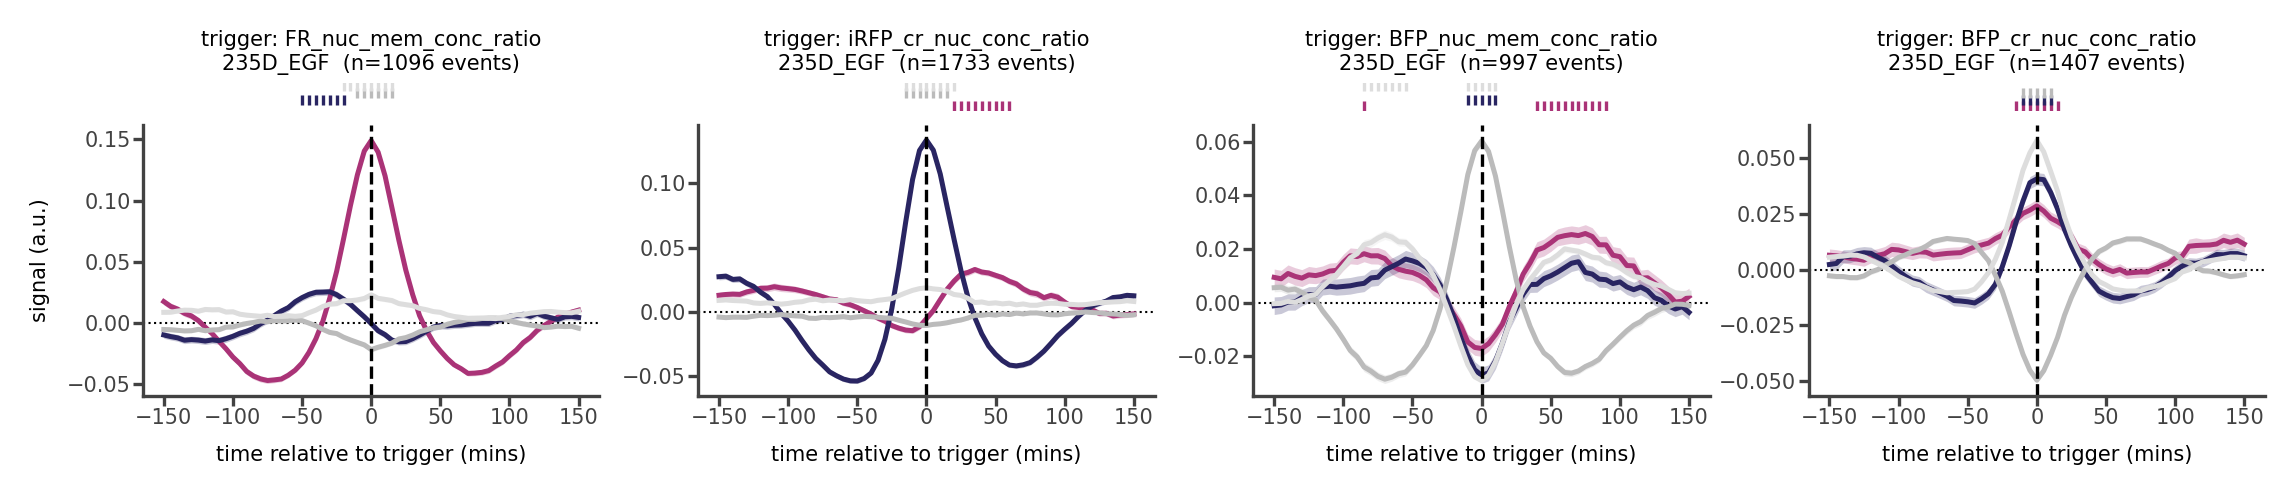

In [200]:


# Step 5 — plot:
plot_style = {"FR_nuc_mem_conc_ratio":{
        'ylim': [0., 0.55],
        'yticks': [0, 0.1,0.2, 0.3, 0.4, 0.5,0.6,0.7],
        'yminorticks': 1,
        'xlim': [-150, 150],
        'xticks': [-200, -100, 0, 100, 200],
        'xminorticks': 2,
},
              "iRFP_cr_nuc_conc_ratio":{
        'ylim': [0., 0.55],
        'yticks': [0, 0.1,0.2, 0.3, 0.4, 0.5,0.6,0.7],
        'yminorticks': 1,
        'xlim': [-150, 150],
        'xticks': [-200, -100, 0, 100, 200],
        'xminorticks': 2,
}
}



fig, axes = plotter.plot_eta_windows(
    windows_list=raw_windows,
    #windows_list=norm_windows,
    # windows_list=[norm_windows_a, norm_windows_b],
    vars=vars,
    trigger_vars=["FR_nuc_mem_conc_ratio", "iRFP_cr_nuc_conc_ratio", "BFP_nuc_mem_conc_ratio", "BFP_cr_nuc_conc_ratio"],
    #trigger_vars=["FR_nuc_conc", "iRFP_nuc_conc"],
    conditions=["235D_EGF"],
    #normalize_mode="baseline_subtract",
    figsize=(1.9,1.6),
    # style=plot_style,
    colors=palette2,
    legend=False,
    show_significance=True,
    effect_size_threshold=0.7,
    file_stem="trigger_ratios_fr0to130_cov07_excl1stpeak_prom0.2-0.3_rela",
)



In [159]:
#now with the raw intensity signals

In [284]:
plotter = PlotHelper(analysis, 
                     palette=palette2, 
                     save_outputs=True, 
                     out_dir=experiment_folder + "plot_exports_nuc_intensities",
                     
                    )
plotter.set_time_axis(dt=5, unit="mins", t_zero=-25)  
# 5 frames then addition of EGF, mineral oil, 5 min interval

In [285]:

vars = ["FR_nuc_conc", 
          "iRFP_nuc_conc",
        "BFP_nuc_conc"]
#invert_vars = None 
invert_vars = ['iRFP_nuc_conc']

outlier_clip=None # for ratios #None for conc

In [286]:
# Step 1 — build and inspect the signal dataframe:

var_params={
        "iRFP_nuc_conc": {
            "detrend": True,      # True
            "detrend_mode": "percentile",   # percentile
            "poly_degree": 1,               # only used if detrend mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False,            #False
            "baseline_window": 41,   #41
            "baseline_pct": 50,#50 prev
            "smooth_sigma": 2.0, #1.0
        },
        "BFP_nuc_conc": {
            "detrend": True,      # True
            "detrend_mode": "percentile",   # percentile
            "poly_degree": 1,               # only used if detrend mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False,            #False
            "baseline_window": 41,   #41
            "baseline_pct": 50,#50 prev
            "smooth_sigma": 2.0, #1.0
        },
        "FR_nuc_conc": {
            "detrend": True,      # True
            "detrend_mode": "percentile",   # percentile
            "poly_degree": 1,               # only used if detrend mode is polynomial, quadratic — try 1 (linear) if still too aggressive
            "smooth_only": False,            #False
            "baseline_window": 41,   #41
            "baseline_pct": 50,#50 prev
            "smooth_sigma": 2.0, #1.0
        },
}

df_indexed = plotter.build_signal_df(
    vars=vars,
    var_params=var_params,
    invert_vars=invert_vars,
    conditions=["235D_EGF"],
    exclude_dividing=False,
    frame_range=[0,130],
    min_coverage=0.9,
    outlier_clip=outlier_clip,
    interpolate_gaps=True,
)

# raw one for the representative trace plot
df_indexed_raw = plotter.build_signal_df(
    vars=vars,
    invert_vars=invert_vars,
    conditions=["235D_EGF"],
    exclude_dividing=False,
    frame_range=[0,130],
    detrend=False,
    min_coverage=0.9,
    outlier_clip=outlier_clip,
    interpolate_gaps=False,
)

# Inspect — should be 0-2 range, no crazy outliers
df_indexed.describe()

[build_signal_df] FR_nuc_conc: 947/4312 cells pass coverage>=0.9
[build_signal_df] iRFP_nuc_conc: 947/4312 cells pass coverage>=0.9
[build_signal_df] BFP_nuc_conc: 947/4312 cells pass coverage>=0.9
[build_signal_df] shape=(120600, 3)
       FR_nuc_conc  iRFP_nuc_conc  BFP_nuc_conc
count  119661.0000    119661.0000   119661.0000
mean        0.0045        -0.0172       -0.0027
std         0.0980         0.1143        0.0573
min        -0.6534        -1.9344       -0.4886
25%        -0.0367        -0.0463       -0.0162
50%        -0.0007        -0.0013       -0.0000
75%         0.0353         0.0340        0.0142
max         3.4429         0.4713        0.9488
[build_signal_df] FR_nuc_conc: 947/4312 cells pass coverage>=0.9
[build_signal_df] iRFP_nuc_conc: 947/4312 cells pass coverage>=0.9
[build_signal_df] BFP_nuc_conc: 947/4312 cells pass coverage>=0.9
[build_signal_df] shape=(124057, 3)
       FR_nuc_conc  iRFP_nuc_conc  BFP_nuc_conc
count  119558.0000    119558.0000   119558.0000
mean

,FR_nuc_conc,iRFP_nuc_conc,BFP_nuc_conc
count,119661.000000,119661.000000,119661.000000
mean,0.004480,-0.017225,-0.002655
std,0.097959,0.114334,0.057262
min,-0.653445,-1.934415,-0.488603
25%,-0.036687,-0.046284,-0.016153
50%,-0.000699,-0.001265,-0.000047
75%,0.035281,0.033997,0.014219
max,3.442905,0.471274,0.948827


[find_peaks_per_cell] 2539 peaks found across 946 cells.
[find_peaks_per_cell] 2837 peaks found across 928 cells.
[find_peaks_per_cell] 2132 peaks found across 888 cells.
  condition folder repeat_id  object_id  peak_frame  peak_value  prominence  \
0  235D_EGF      1        18          6          55    0.092319    0.137295   
1  235D_EGF      1        18          6          81    0.012060    0.074633   
2  235D_EGF      1        18          6         119    0.097786    0.112259   
3  235D_EGF      1        18          7          19    0.040095    0.116680   
4  235D_EGF      1        18          7          47    0.146560    0.276168   

   pulse_number  
0             1  
1             2  
2             3  
3             1  
4             2  


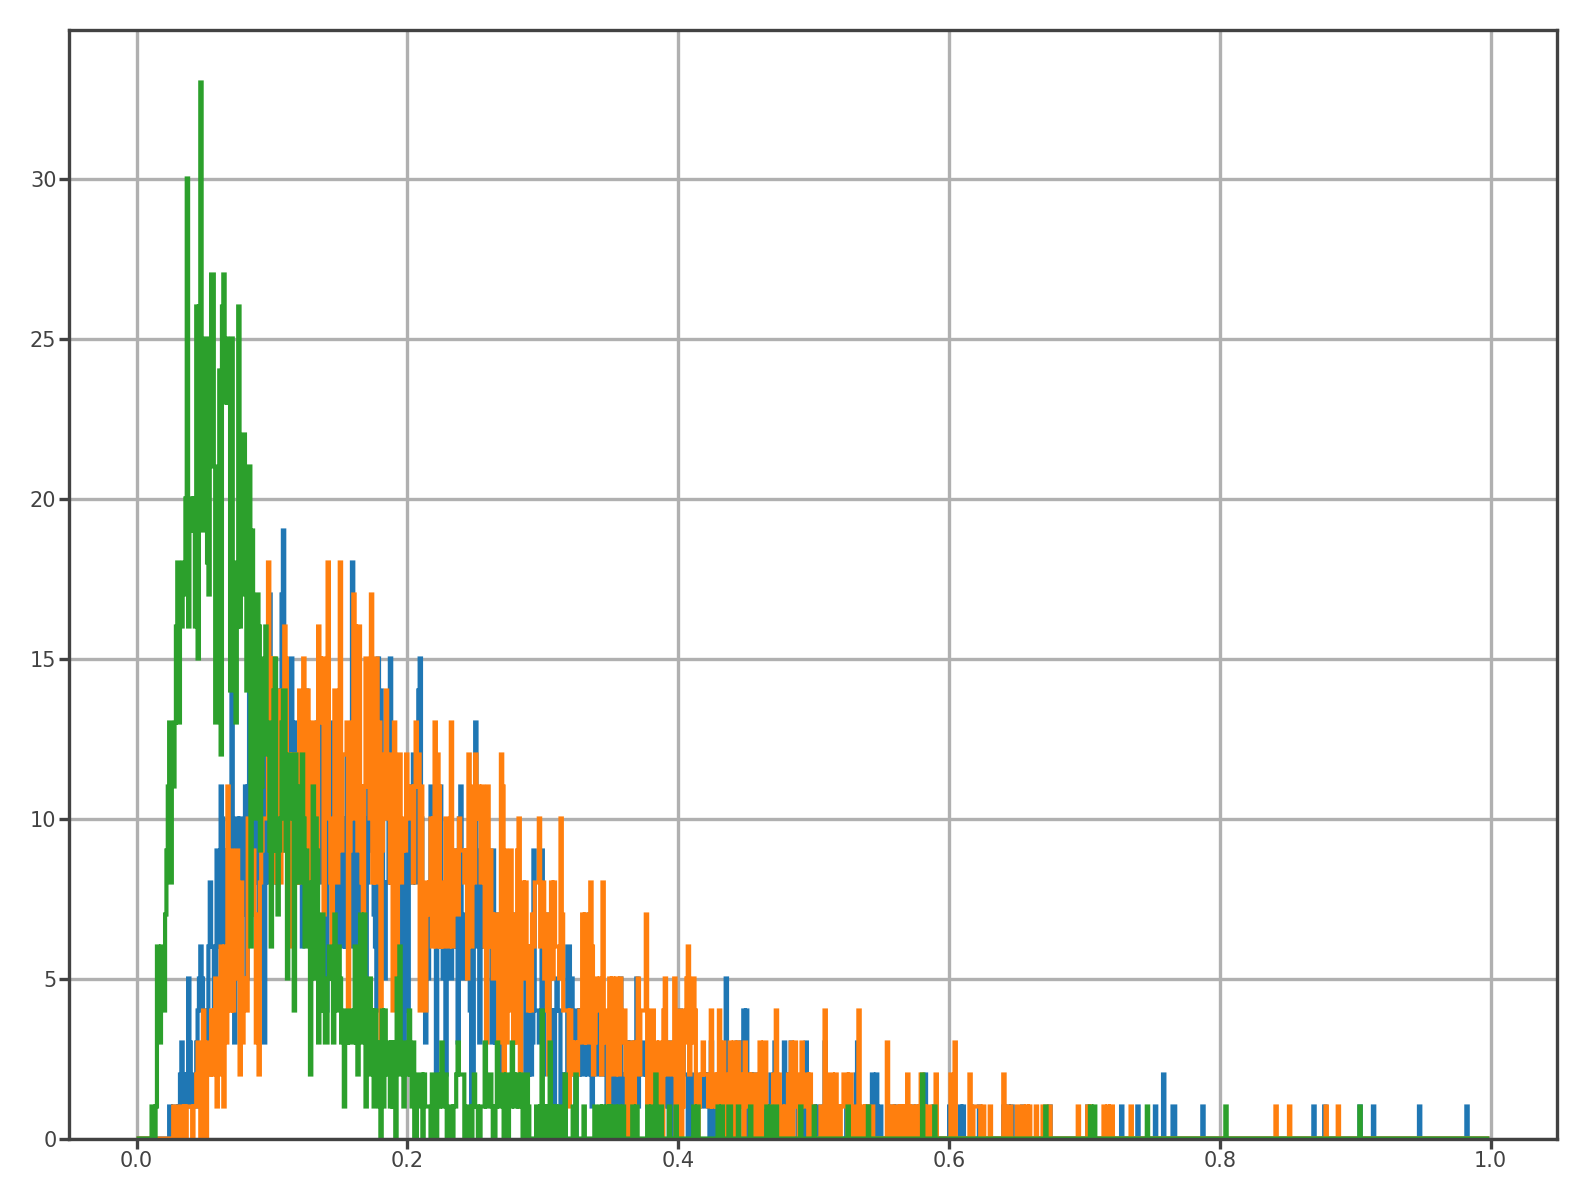

In [287]:
# Step 2 — detect peaks and inspect them:


peak_params={
        "iRFP_nuc_conc": {
            "prominence": 0.2, #0.2
            "relative_prominence": True, #True
            "distance": 5, #10
            "width": 3, #3
            # "height": 40,
        },
        "BFP_nuc_conc": {
            "prominence": 0.2, #0.2
            "relative_prominence": True, #True
            "distance": 5, #10
            "width": 3,#3
            # "height": 40,
        },
        "FR_nuc_conc": {
            "prominence": 0.2, #0.2
            "relative_prominence": True, #True
            "distance": 5, #10
            "width": 3, #3
            # "height": 40,
        },
}

peaks = []
for var in vars:
    new_peak = plotter.find_peaks_per_cell(
        var,
        conditions=["235D_EGF"],
        df_indexed=df_indexed,
        prominence=peak_params[var]['prominence'],
        distance=peak_params[var]['distance'],
        relative_prominence=peak_params[var]['relative_prominence'],
        width=peak_params[var]['width'],
        # height=0.06,
        detrend=False,
    )
    peaks.append(new_peak)

# Inspect — check distribution of peak values and prominences
for peak in peaks:
    peak["prominence"].hist(bins=np.arange(0, 1.0, 0.001), histtype='step')
# peaks[0]["prominence"].hist(bins=30)
print(peaks[0].head())

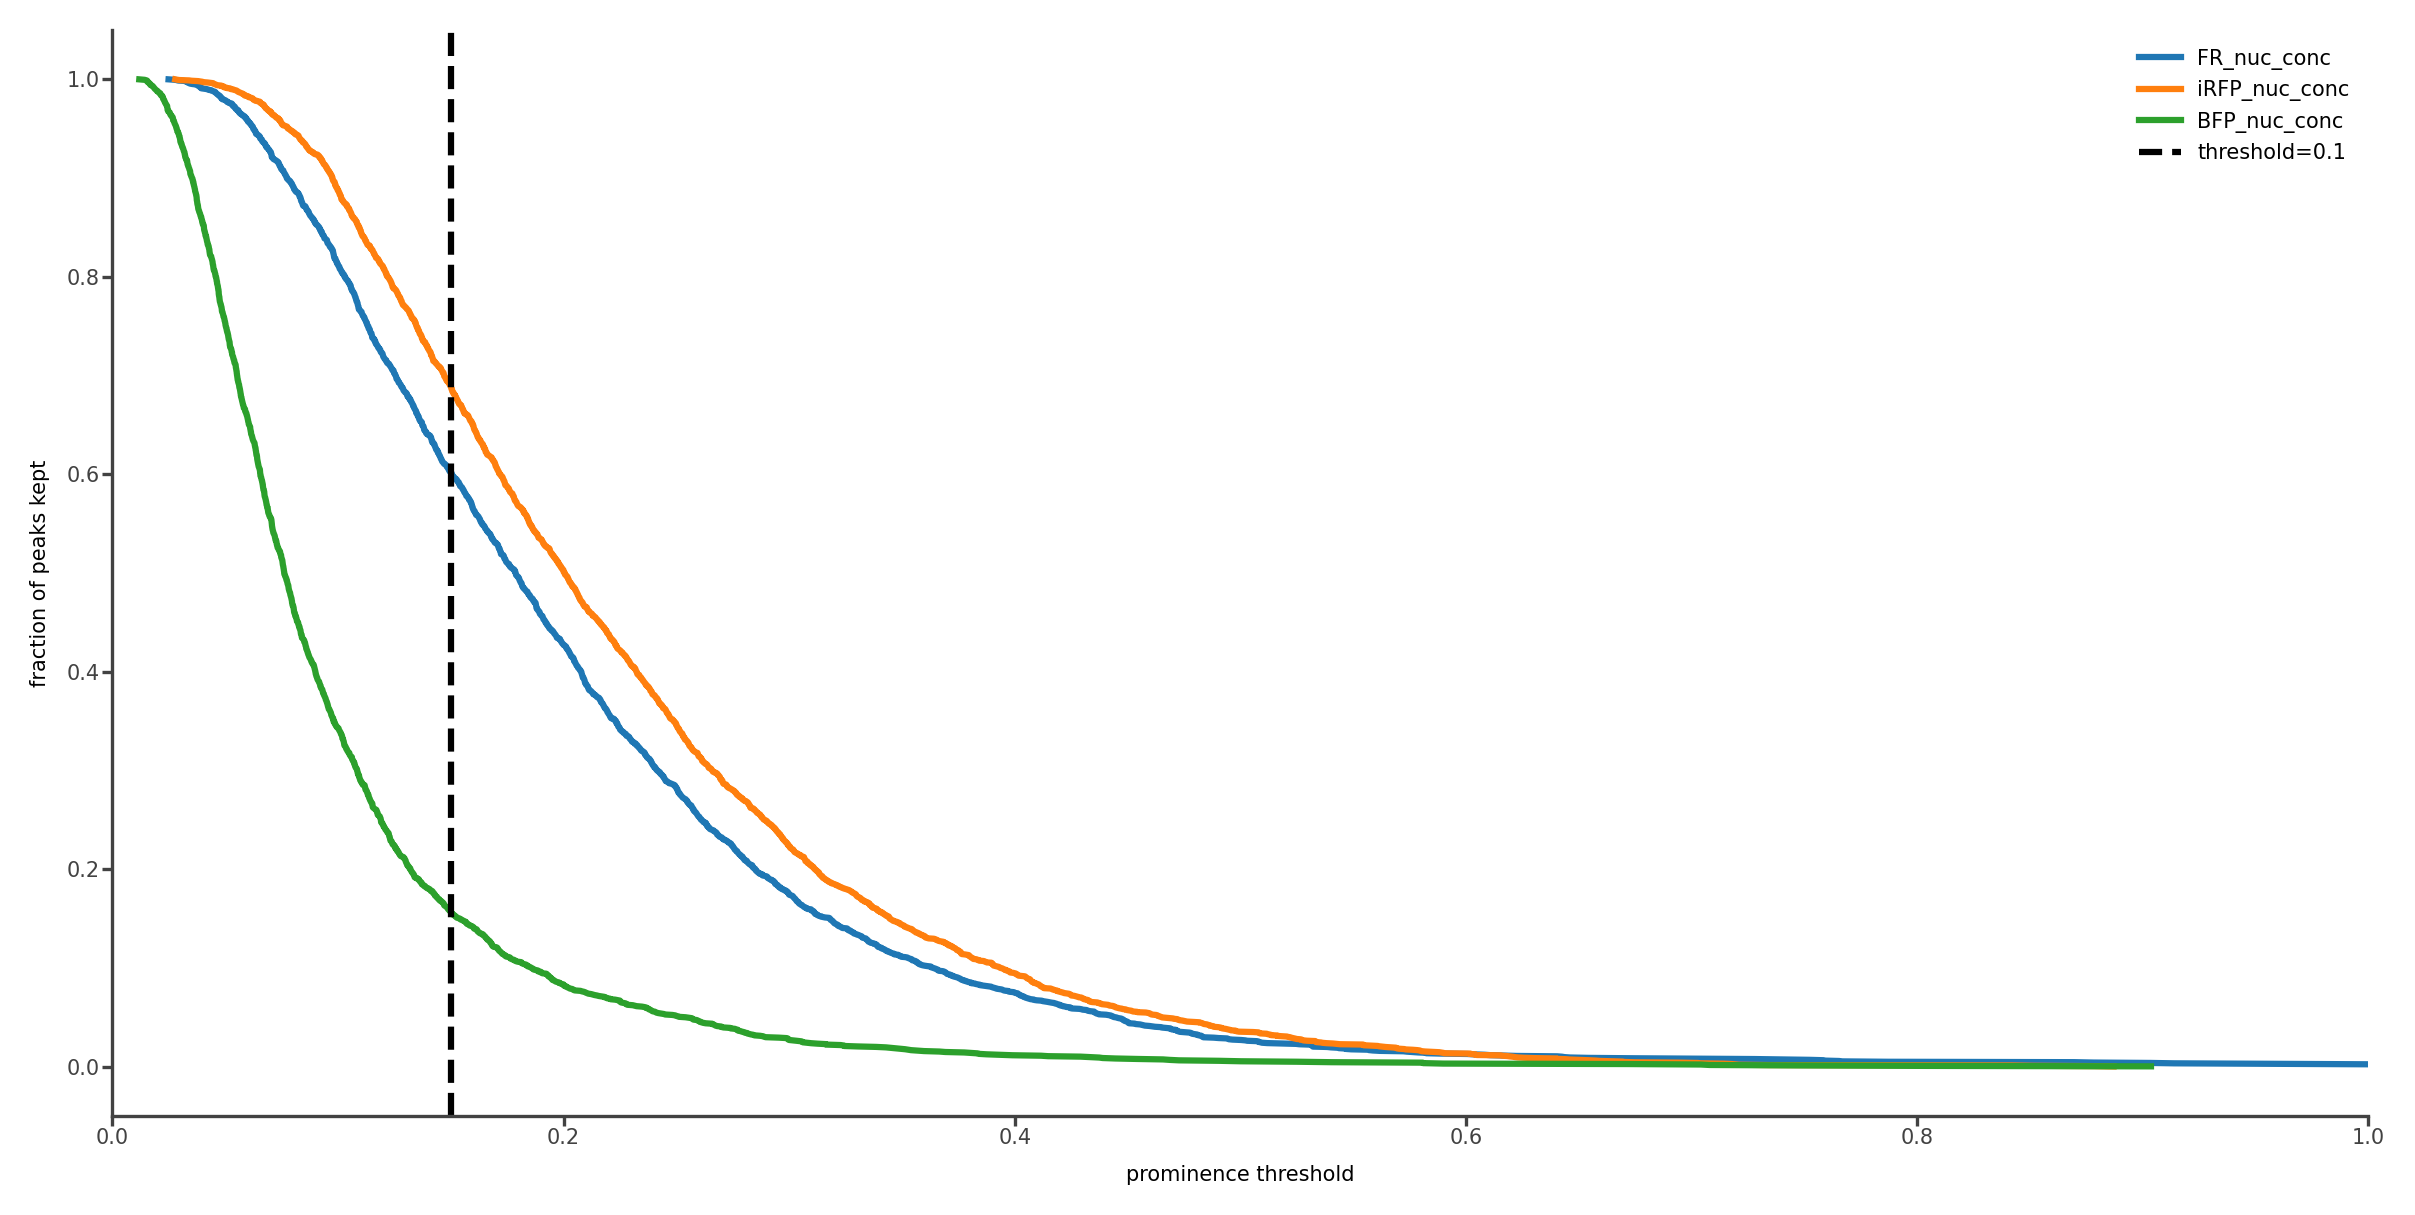

In [288]:
# Plot cumulative fraction to find a threshold that keeps e.g. top 20% of peaks
fig, ax = plt.subplots(figsize=(8, 4))
for peaks_df, var in zip(peaks, vars):
    sorted_prom = np.sort(peaks_df["prominence"].values)
    cdf = np.arange(len(sorted_prom)) / len(sorted_prom)
    ax.plot(sorted_prom, 1 - cdf, label=var)
ax.set_xlabel("prominence threshold")
ax.set_ylabel("fraction of peaks kept")
ax.axvline(0.15, linestyle="--", color="k", label="threshold=0.1")
ax.set_xlim(0, 1.0)    # zoom x axis
# ax.set_ylim(0, 0.5)    # zoom y axis — show only top 50% of peaks
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

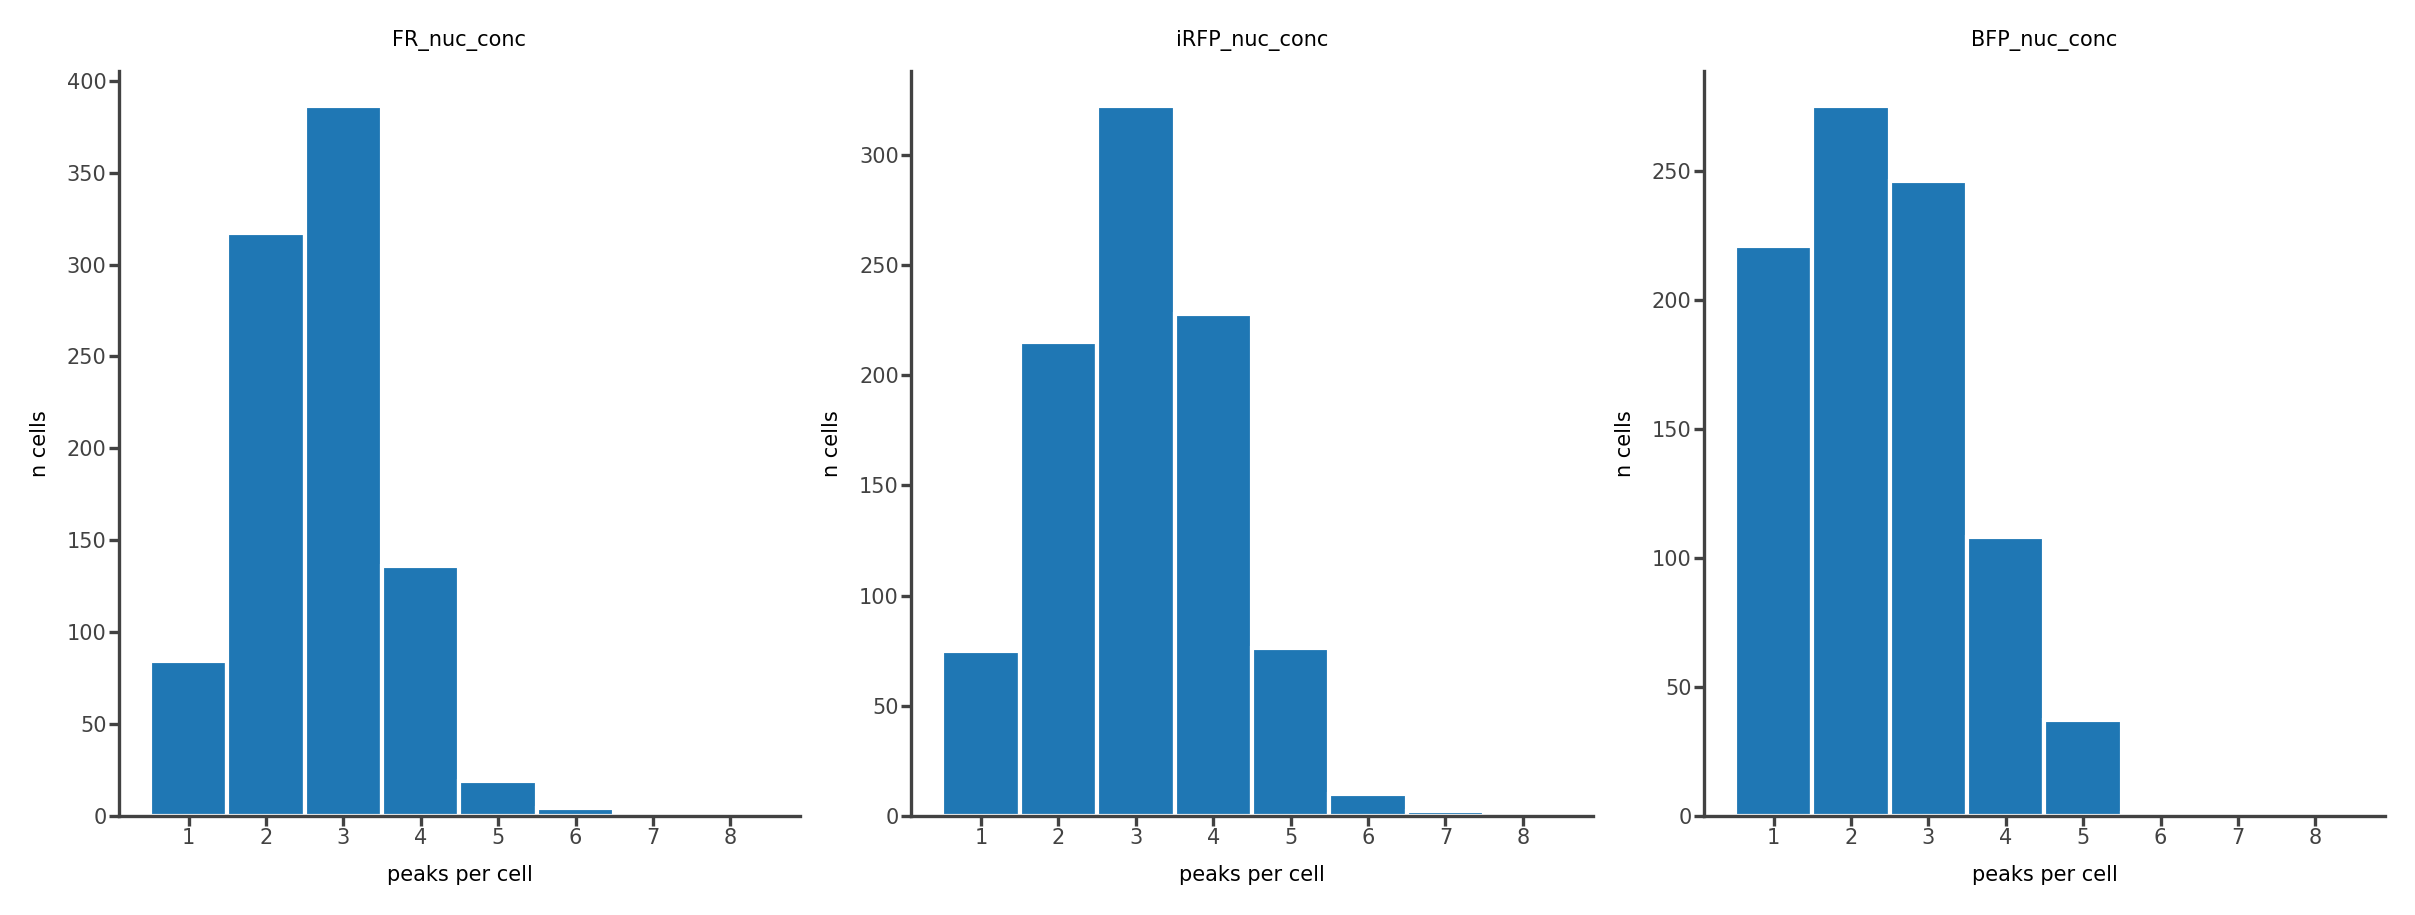

In [289]:
fig, axes = plt.subplots(1, len(peaks), figsize=(8, 3))

for ax, peak, title in zip(
    axes,
    peaks,
    vars
):
    counts = peak.groupby(
        ["condition", "folder", "repeat_id", "object_id"]
    ).size()
    ax.hist(counts.values, bins=range(1, 10), 
            align="left", edgecolor="white")
    ax.set_xlabel("peaks per cell")
    ax.set_ylabel("n cells")
    ax.set_title(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [290]:
for peak, var in zip(peaks, vars):
    counts = peak.groupby(
        ["condition", "folder", "repeat_id", "object_id"]
    ).size()
    print(f"{var}: {counts.mean():.2f} ± {counts.std():.2f} peaks/cell (n={len(counts)})")

FR_nuc_conc: 2.68 ± 0.92 peaks/cell (n=946)
iRFP_nuc_conc: 3.06 ± 1.12 peaks/cell (n=928)
BFP_nuc_conc: 2.40 ± 1.12 peaks/cell (n=888)


Plotting cell: {'condition': '235D_EGF', 'folder': '3', 'repeat_id': '19', 'object_id': 122}  (567 candidates)
[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/c235D_EGF-f3-r19-o122_s5_p2.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/c235D_EGF-f3-r19-o122_s5_p2_points.csv


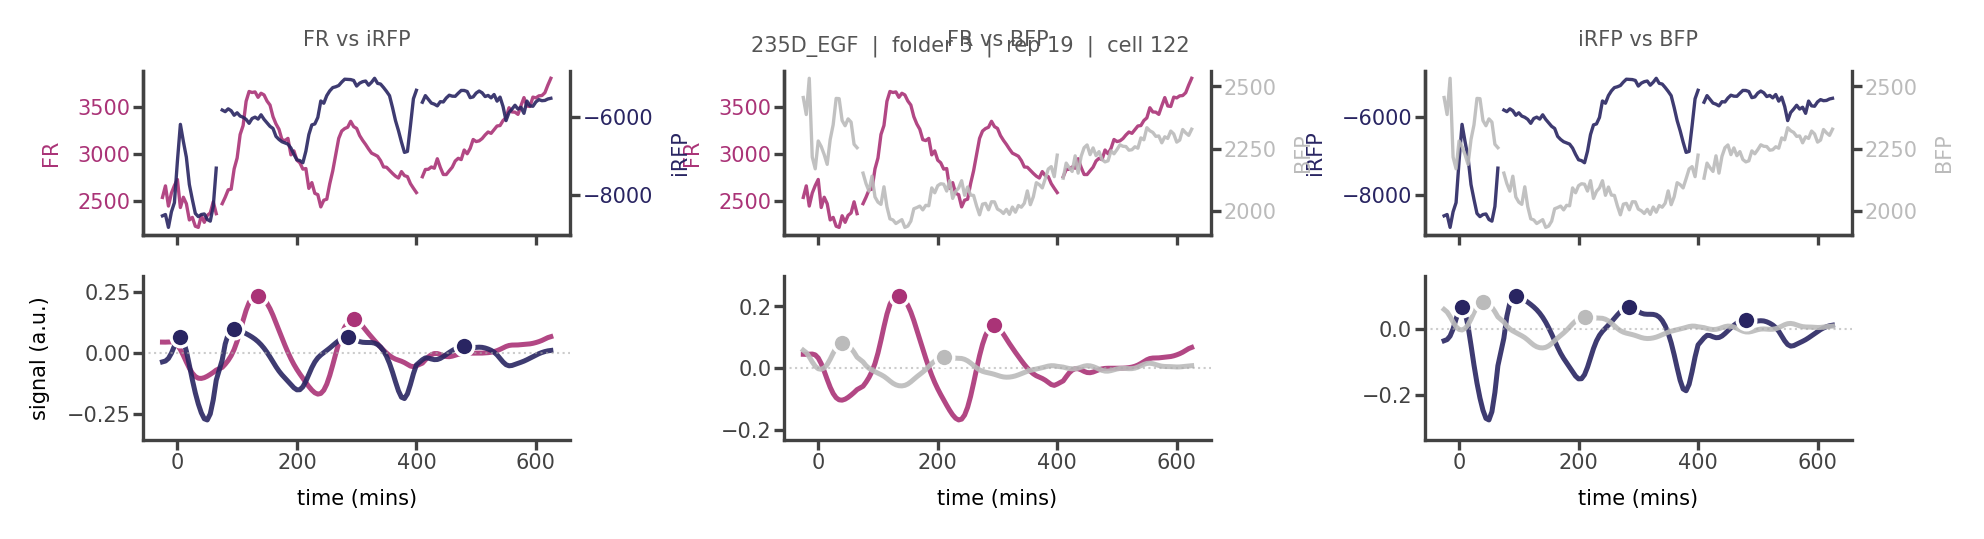

[save_cell_tiffs] Saved crop        → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/celltrack_img_files/c235D_EGF-f3-r19-o122_raw_img.tif
[save_cell_tiffs] Saved outline full → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/celltrack_img_files/c235D_EGF-f3-r19-o122_cell_outline_full.tif
[save_cell_tiffs] Saved outline crop → /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/celltrack_img_files/c235D_EGF-f3-r19-o122_cell_outline_crop.tif


PosixPath('/fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/celltrack_img_files')

In [300]:

# Random cell with peaks in all vars
# fig, cell = plot_representative_traces_with_peaks(
#     plotter=plotter,
#     df_raw_indexed=df_indexed_raw,
#     df_proc_indexed=df_indexed,
#     peaks_list=[peaks[0], peaks[1]],
#     vars=[vars[0], vars[1]],
#     colors={
#         vars[0]:  "#aa3377",
#         vars[1]: "#292562",
#     },
#     conditions=["235D_EGF"],
#     seed=42,
#     min_peaks=2,
# )

# Pin to a specific cell found in the hist2d
fig, cell = plotter.plot_representative_traces_with_peaks(
    df_raw_indexed=df_indexed_raw,
    df_proc_indexed=df_indexed,
    peaks_list=[peaks[0], peaks[1],peaks [2]],
    vars=[vars[0],vars[1], vars[2]],
    counts_df=counts_df,   # restricts to cells from the hist2d
    conditions=["235D_EGF"],
    pairs=[
        ("FR_nuc_conc",  "iRFP_nuc_conc"),
        ("FR_nuc_conc",  "BFP_nuc_conc"),
        ("iRFP_nuc_conc",  "BFP_nuc_conc"),
    ],
    colors={
        vars[0]:  "#aa3377",
        vars[1]: "#292562",
        vars[2]: "#BBBBBB",
    },
    
    seed=5,   # for prominence 0.5, seed 5, min_peaks=3 worked well 235D_EGF folder 3 rep 8
    min_peaks=2,
    figsize=(7.35,1.5),
    #file_stem="test",
 #cell_f3_r8_o203_ratios seed7. minpeak3, cell_f3_r7_o53_s8_p3_ratios, cell_f3_r8_o161_s13_p3_ratios, f3_r8_o197_s15_p3_ratios,cell_f2_r8_o282_s16_p3_ratios, cell_f3_r8_o161_s18_p3_ratios,cell_f3_r19_o83_s19_p3_ratios, cell_f3_r7_o251_s3_p2_ratios,cell_f1_r5_o17_s30_p2_ratios
)


#from plotting_functions import save_cell_tiffs

from plotting_functions import save_cell_tiffs
#save_cell_tiffs(cell, plotter.analysis, plotter, save_crop=False, save_outline=False)
save_cell_tiffs(cell, plotter.analysis, plotter, save_crop=True, save_outline=True)

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/peak_counts_EGF.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/peak_counts_EGF_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/peak_counts_EGF_summary.csv


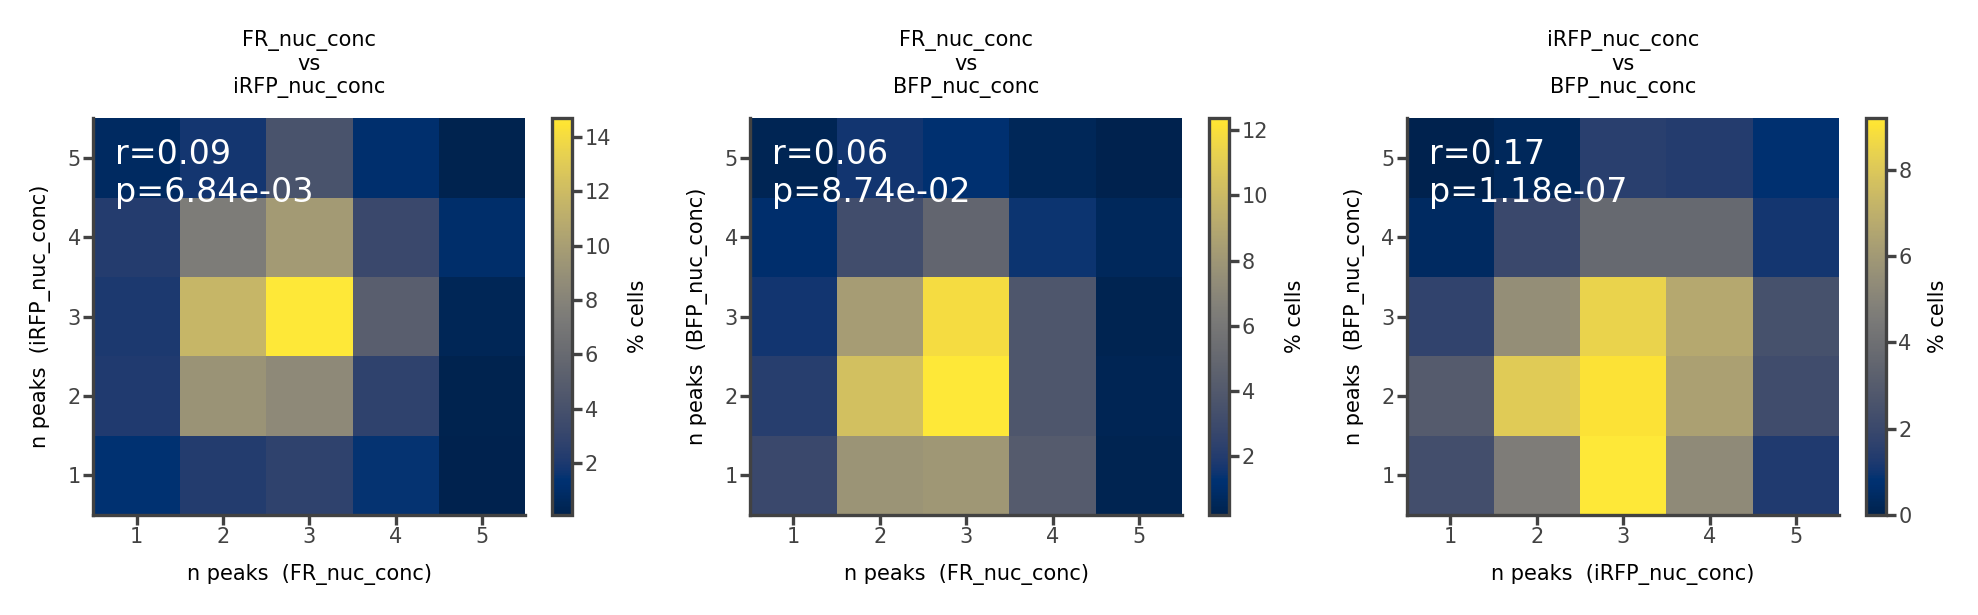

In [292]:
plot_style = {
        'ylim': [0., 0.55],
        'yticks': [0, 0.1,0.2, 0.3, 0.4, 0.5,0.6,0.7],
        'yminorticks': 1,
        'xlim': [-150, 150],
        'xticks': [-200, -100, 0, 100, 200],
        'xminorticks': 2,
}

fig, axes, counts_df = plotter.plot_peak_count_hist2d(
    peaks_list=peaks,
    var_names=vars,
    conditions=["235D_EGF"],
    normalize=True,
    file_stem="peak_counts_EGF",
    figsize=(2.2,2),
    bins = np.arange(0.5, 6.5, 1),
)

/fml/ag-ramm/projects/Protease_biosensor/scripts/final_scripts_analysis/plotting_functions.py:5349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _palette = palette or [f"C{i}" for i in range(max_pulses)]
/fml/ag-ramm/projects/Protease_biosensor/scripts/final_scripts_analysis/plotting_functions.py:5349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _palette = palette or [f"C{i}" for i in range(max_pulses)]
/fml/ag-ramm/projects/Protease_biosensor/scripts/final_scripts_analysis/plotting_functions.py:5349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _palette = palette or [f"C{

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/pulse_prominence_EGF_intensities.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/pulse_prominence_EGF_intensities_points.csv


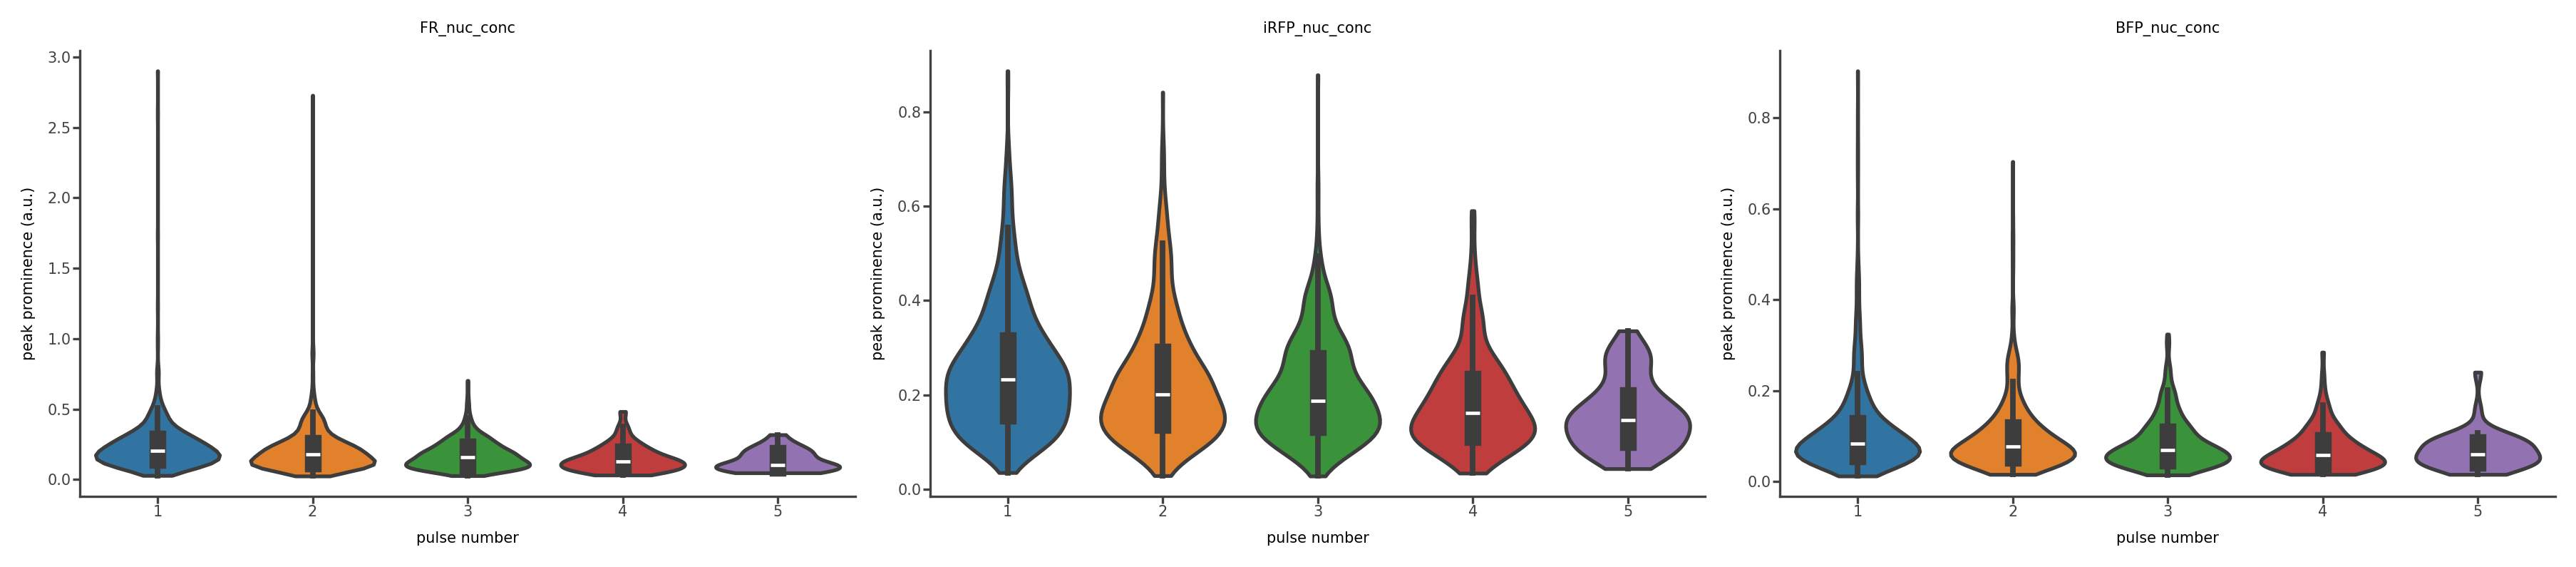

In [293]:
fig, axes, df_numbered = plotter.plot_pulse_prominence_by_number(
    peaks_list=peaks,
    var_names=vars,
    conditions=["235D_EGF"],
    max_pulses=5,
    file_stem="pulse_prominence_EGF_intensities",
)

In [294]:
# Compare pulse 1 vs mean of pulses 2-5 for a given variable

cell_keys = ["condition", "folder", "repeat_id", "object_id"]
var_df = df_numbered[df_numbered["variable"] == "FR_nuc_mem_conc_ratio"]

pulse1 = var_df[var_df["pulse_number"] == 1].set_index(cell_keys)["prominence"]
later  = var_df[var_df["pulse_number"] > 1].groupby(cell_keys)["prominence"].mean()

paired = pd.concat([pulse1, later], axis=1)
paired.columns = ["pulse_1", "pulse_2_5_mean"]
paired = paired.dropna()
print(paired.describe())

       pulse_1  pulse_2_5_mean
count      0.0             0.0
mean       NaN             NaN
std        NaN             NaN
min        NaN             NaN
25%        NaN             NaN
50%        NaN             NaN
75%        NaN             NaN
max        NaN             NaN


In [295]:
# Step 3 — extract raw windows and inspect them:
raw_windows_a = raw_windows[0]
PRE  = 30
POST = 30

raw_windows = []
for peak in peaks:
    raw_windows.append(
        plotter.extract_eta_windows(
        df_indexed=df_indexed,
        peaks_df=peak,
        extract_vars=vars,
        pre=PRE,
        post=POST,
        # exclude_first_n_frames=40,
        skip_first_peak=True,
        require_full_window=False,
        pre_std_threshold=None #1.0,   # flat pre-window filter
        )
    )

# Inspect — check shapes and value ranges before normalisation
for var, X in raw_windows_a["235D_EGF"]["windows"].items():
    print(f"{var}: shape={X.shape}, mean={X.mean():.3f}, std={X.std():.3f}")



[extract_eta_windows] 235D_EGF: 1593 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
[extract_eta_windows] 235D_EGF: 1909 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
[extract_eta_windows] 235D_EGF: 1244 events kept  |  rejected: 0 (incomplete window)  0 (noisy pre-window)
FR_nuc_conc: shape=(1593, 61), mean=nan, std=nan
iRFP_nuc_conc: shape=(1593, 61), mean=nan, std=nan
BFP_nuc_conc: shape=(1593, 61), mean=nan, std=nan


In [296]:
# Step 4 — normalise and inspect:

norm_windows = []

for raw_win in raw_windows:
    norm_windows.append(
        plotter.normalise_eta_windows(
            cond_results=raw_win,
            pre=PRE,
            mode="baseline_subtract",
        )
    )

# Inspect — now should be centred around 0
for var, X in norm_windows[0]["235D_EGF"]["windows"].items():
    print(f"{var}: mean={X.mean():.3f}, std={X.std():.3f}")


FR_nuc_conc: mean=nan, std=nan
iRFP_nuc_conc: mean=nan, std=nan
BFP_nuc_conc: mean=nan, std=nan


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/trigger_int_fr0to130_cov07_excl1stpeak_prom0.2-0.3_rela.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A-EGF_newseg_EGFtracking_tracking_ownversion/plot_exports_nuc_intensities/trigger_int_fr0to130_cov07_excl1stpeak_prom0.2-0.3_rela_points.csv


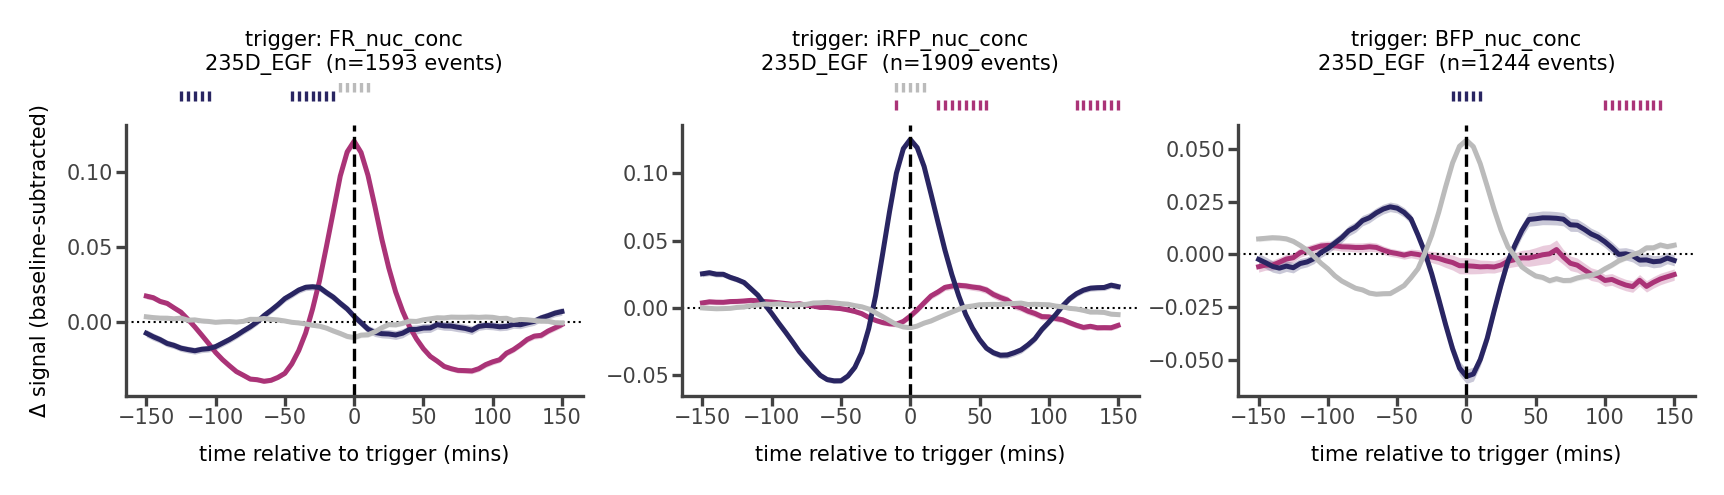

In [297]:
# Step 5 — plot:
plot_style = {"FR_nuc_mem_conc_ratio":{
        'ylim': [0., 0.55],
        'yticks': [0, 0.1,0.2, 0.3, 0.4, 0.5,0.6,0.7],
        'yminorticks': 1,
        'xlim': [-150, 150],
        'xticks': [-200, -100, 0, 100, 200],
        'xminorticks': 2,
},
              "iRFP_cr_nuc_conc_ratio":{
        'ylim': [0., 0.55],
        'yticks': [0, 0.1,0.2, 0.3, 0.4, 0.5,0.6,0.7],
        'yminorticks': 1,
        'xlim': [-150, 150],
        'xticks': [-200, -100, 0, 100, 200],
        'xminorticks': 2,
}
}


fig, axes = plotter.plot_eta_windows(
    # windows_list=raw_windows,
    windows_list=norm_windows,
    # windows_list=[norm_windows_a, norm_windows_b],
    vars=vars,
    trigger_vars=vars,
    #trigger_vars=["FR_nuc_conc", "iRFP_nuc_conc"],
    conditions=["235D_EGF"],
    normalize_mode="baseline_subtract",
    figsize=(1.9,1.6),
    # style=plot_style,
    colors=palette2,
    legend=False,
    show_significance=True,
    effect_size_threshold=0.7,
    file_stem= "trigger_int_fr0to130_cov07_excl1stpeak_prom0.2-0.3_rela",
)
    


In [303]:
print(f"helloworld")

helloworld


In [309]:
import importlib
for name in ["numpy", "pandas", "scipy", "matplotlib", "seaborn", "tifffile", "skimage", "imageio"]:
    try:
        pkg = importlib.import_module(name)
        print(f"{name}: {pkg.__version__}")
    except Exception as e:
        print(f"{name}: not found ({e})")

numpy: 2.0.2
pandas: 3.0.1
scipy: 1.17.1
matplotlib: 3.10.8
seaborn: 0.13.2
tifffile: 2026.3.3
skimage: not found (No module named 'skimage')
imageio: not found (No module named 'imageio')


In [310]:
import IPython, jupyter_core
print(f"IPython: {IPython.__version__}")
print(f"jupyter_core: {jupyter_core.__version__}")

IPython: 9.10.1
jupyter_core: 5.9.1


In [311]:
import sys
print(f"Python: {sys.version}")

Python: 3.11.15 (main, Mar 24 2026, 22:50:29) [Clang 22.1.1 ]
